In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import overload
from datetime import datetime
from copy import deepcopy
import os

SEED = 9
torch.manual_seed(SEED)
np.random.seed(SEED)

plt.rcParams["font.family"] = "Open Sans"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("Imports loaded.")

Using device: cpu
Imports loaded.


In [2]:
GAMMA = 1.4
X_START, X_THROAT, X_LENGTH = 0.0, 0.5, 1.0
X_SHOCK_REF = 0.75  # reference/expected shock location
x_shock = 0.75  # initial single_loss_historyguess, updated after shock detection

# pseudo-time horizon: run long enough that transient has died out
T_STEADY = 5.0  # evaluate steady state at this pseudo-time
T_MAX = T_STEADY  # domain upper bound in t

BD_DELTA = 1e-5  # mask width for inlet/exit/IC point selection
EVAL_PRED_POINTS = 2000  # number of points to evaluate the final solution

# ── shock detection hyper-parameters ──────────────────────────────────────────
SHOCK_DET_POINTS = 2000
SHOCK_DET_ADAM_EPOCHS = 1500
SHOCK_DET_LBFGS_EPOCHS = 1000
SHOCK_DET_ADAM_LR = 1e-3
SHOCK_DET_RESAMPLE_EVERY = 500
SHOCK_DET_LBFGS_RESAMPLE_EVERY = 500
SHOCK_DET_PRINT_EVERY = 500
SHOCK_DET_GRAD_CLIP = 1.0
SHOCK_DET_BC_WEIGHT = 10.0
SHOCK_FORMATION_TOL = 1e-1

# ── dual-network hyper-parameters ─────────────────────────────────────────────
DUAL_NET_POINTS = 1000
DUAL_NET_TIME_SAMPLES = 200
DUAL_NET_ADAM_EPOCHS = 6000
DUAL_NET_LBFGS_EPOCHS = 1000
DUAL_NET_ADAM_LR = 1e-3
DUAL_NET_SHOCK_LR = 1e-4
DUAL_NET_RESAMPLE_EVERY = 1000
DUAL_NET_LBFGS_RESAMPLE_EVERY = 1000
DUAL_MAX_CONSECUTIVE_NAN = 5
DUAL_NET_PRINT_EVERY = 500
DUAL_NET_GRAD_CLIP = 1.0
DUAL_NET_BC_WEIGHT = 10.0
DUAL_NET_INTERFACE_WEIGHT = 10.0
DUAL_NET_SHOCK_PRIOR_WEIGHT = 5.0

REMESH_EVERY = 600  # re-mesh every this many epochs during dual-net training
REMESH_SHIFT_TOL = 1e-3

SHOCK_DET_MODEL_NAME = "shock_det_model"
DUAL_NET_PRE_MODEL_NAME = "dual_net_pre_model"
DUAL_NET_POST_MODEL_NAME = "dual_net_post_model"
INTERFACE_MODEL_NAME = "interface_model"


@overload
def get_area(x: float) -> float: ...
@overload
def get_area(x: np.ndarray) -> np.ndarray: ...
@overload
def get_area(x: torch.Tensor) -> torch.Tensor: ...
def get_area(x):
    return 1.0 + 2.2 * (x - X_THROAT) ** 2.0


@overload
def get_d_area(x: float) -> float: ...
@overload
def get_d_area(x: np.ndarray) -> np.ndarray: ...
@overload
def get_d_area(x: torch.Tensor) -> torch.Tensor: ...
def get_d_area(x):
    return 4.4 * (x - X_THROAT)


print("Constants defined.")

Constants defined.


In [5]:
def _bisection_for_mach_no(a: float, supersonic: bool) -> float:
    def func(M):
        t = 1.0 + (GAMMA - 1.0) / 2.0 * M**2.0
        expo = (GAMMA + 1.0) / (2.0 * (GAMMA - 1.0))
        return (1.0 / M) * (2.0 / (GAMMA + 1.0) * t) ** expo - a

    low, high = (1.0 + BD_DELTA, 10.0) if supersonic else (BD_DELTA, 1.0 - BD_DELTA)
    for _ in range(300):
        mid = (low + high) / 2
        if func(mid) * func(low) < 0:
            high = mid
        else:
            low = mid
    return (low + high) / 2


class AnalyticSolution:
    def __init__(self, n_points: int = EVAL_PRED_POINTS):
        self.x_shock = X_SHOCK_REF
        self.x = np.linspace(X_START, X_START + X_LENGTH, n_points)
        self._solve()

    def _solve(self):
        x, x_shock = self.x, self.x_shock
        A = get_area(x)
        M = np.empty_like(x)

        sub_mask = x <= X_THROAT
        pre_mask = (x > X_THROAT) & (x <= x_shock)
        post_mask = x > x_shock

        for i in np.where(sub_mask)[0]:
            M[i] = _bisection_for_mach_no(A[i].item(), supersonic=False)
        for i in np.where(pre_mask)[0]:
            M[i] = _bisection_for_mach_no(A[i].item(), supersonic=True)

        M1 = _bisection_for_mach_no(get_area(x_shock), supersonic=True)
        M2 = np.sqrt(
            (1.0 + (GAMMA - 1.0) / 2.0 * M1**2.0)
            / (GAMMA * M1**2.0 - (GAMMA - 1.0) / 2.0)
        )

        p02_by_p01 = (
            (((GAMMA + 1.0) * M1**2.0) / (2.0 + (GAMMA - 1.0) * M1**2.0))
            ** (GAMMA / (GAMMA - 1.0))
        ) * (
            ((GAMMA + 1.0) / (2.0 * GAMMA * M1**2.0 - GAMMA + 1.0))
            ** (1.0 / (GAMMA - 1.0))
        )

        a_star_2_by_a_star_1 = 1.0 / p02_by_p01

        for i in np.where(post_mask)[0]:
            a_eff = A[i] / a_star_2_by_a_star_1
            M[i] = _bisection_for_mach_no(a_eff, supersonic=False)

        T0 = np.ones_like(x)
        P0 = np.where(post_mask, p02_by_p01, 1.0)
        rho0 = P0 / T0

        T = T0 / (1.0 + (GAMMA - 1.0) / 2.0 * M**2.0)
        P = P0 * (1.0 + (GAMMA - 1.0) / 2.0 * M**2.0) ** (-GAMMA / (GAMMA - 1.0))
        rho = rho0 * (1.0 + (GAMMA - 1.0) / 2.0 * M**2.0) ** (-1.0 / (GAMMA - 1.0))

        self.M, self.P, self.T, self.rho = M, P, T, rho
        self.sub_mask, self.pre_mask, self.post_mask = sub_mask, pre_mask, post_mask
        self.M1, self.M2, self.p02_by_p01 = M1, M2, p02_by_p01
    
    def data(self, region: str):
        match region:
            case "subsonic": mask = self.sub_mask
            case "supersonic": mask = self.pre_mask
            case "post-shock": mask = self.post_mask
            case _:
                raise ValueError(f"Unknown region: {region}")
        
        return self.x[mask], (self.M[mask], self.P[mask], self.T[mask], self.rho[mask])


analytic = AnalyticSolution()
_M_INLET = _bisection_for_mach_no(get_area(X_START), supersonic=False)
RHO_INLET = (1.0 + (GAMMA - 1.0) / 2.0 * _M_INLET**2.0) ** (-1.0 / (GAMMA - 1.0))
T_INLET = 1.0 / (1.0 + (GAMMA - 1.0) / 2.0 * _M_INLET**2.0)
P_INLET = RHO_INLET * T_INLET
U_INLET = _M_INLET * np.sqrt(GAMMA * T_INLET)
P_EXIT = analytic.P[-1]

print(f"P_EXIT={P_EXIT:.4f}  U_INLET={U_INLET:.4f}")
print("Analytical reference solution computed.")

P_EXIT=0.8289  U_INLET=0.4804
Analytical reference solution computed.


In [6]:
def _bisection_for_mach_no(a: float, supersonic: bool) -> float:
    def func(M):
        t = 1.0 + (GAMMA - 1.0) / 2.0 * M**2.0
        expo = (GAMMA + 1.0) / (2.0 * (GAMMA - 1.0))
        return (1.0 / M) * (2.0 / (GAMMA + 1.0) * t) ** expo - a

    low, high = (1.0 + BD_DELTA, 10.0) if supersonic else (BD_DELTA, 1.0 - BD_DELTA)
    for _ in range(300):
        mid = (low + high) / 2
        if func(mid) * func(low) < 0:
            high = mid
        else:
            low = mid
    return (low + high) / 2


def get_back_pressure_from_shock(x_shock_loc: float) -> float:
    A_shock = get_area(x_shock_loc)
    M_pre = _bisection_for_mach_no(A_shock, supersonic=True)
    p02_p01 = (
        ((GAMMA+1)*M_pre**2 / (2 + (GAMMA-1)*M_pre**2)) ** (GAMMA/(GAMMA-1))
        * ((GAMMA+1) / (2*GAMMA*M_pre**2 - (GAMMA-1))) ** (1/(GAMMA-1))
    )
    A_exit = get_area(X_LENGTH)
    M_exit = _bisection_for_mach_no(max(A_exit * p02_p01, 1.0 + 1e-6), supersonic=False)
    return (1.0 + (GAMMA-1)/2.0 * M_exit**2) ** (-GAMMA/(GAMMA-1)) * p02_p01

def get_inlet_mach() -> float:
    return _bisection_for_mach_no(get_area(X_START), supersonic=False)


P_EXIT = get_back_pressure_from_shock(X_SHOCK_REF)
_M_INLET = get_inlet_mach()
RHO_INLET = (1.0 + (GAMMA - 1.0) / 2.0 * _M_INLET**2.0) ** (-1.0 / (GAMMA - 1.0))
T_INLET = 1.0 / (1.0 + (GAMMA - 1.0) / 2.0 * _M_INLET**2.0)
P_INLET   = RHO_INLET * T_INLET
U_INLET = _M_INLET * np.sqrt(GAMMA * T_INLET)

print(f"P_EXIT={P_EXIT:.4f}  M_INLET={_M_INLET:.4f}  U_INLET={U_INLET:.4f}")
print("Reference data loaded.")

P_EXIT=0.8289  M_INLET=0.4129  U_INLET=0.4804
Reference data loaded.


In [3]:
class UnsteadyNet(nn.Module):
    """
    (x, t) -> (rho, u, P, T)
    """

    INPUT = 2
    OUTPUT = 4

    def __init__(self, hid_dim: int = 128, num_hidden: int = 3):
        super().__init__()
        layers = [nn.Linear(self.INPUT, hid_dim), nn.Tanh()]
        for _ in range(num_hidden):
            layers += [nn.Linear(hid_dim, hid_dim), nn.Tanh()]
        layers += [nn.Linear(hid_dim, self.OUTPUT)]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="tanh")
                nn.init.zeros_(m.bias)

    def forward(self, xt: torch.Tensor):
        out = self.net(xt)
        rho_raw, u_raw, p_raw, T_raw = (
            out[:, 0:1],
            out[:, 1:2],
            out[:, 2:3],
            out[:, 3:4],
        )

        rho = nn.functional.softplus(rho_raw + 1.0)
        u = nn.functional.softplus(u_raw + 1.0)
        P = nn.functional.softplus(p_raw + 1.0)
        T = nn.functional.softplus(T_raw + 1.0)

        return torch.cat([rho, u, P, T], dim=1)


print("UnsteadyNet defined.")

UnsteadyNet defined.


In [4]:
def sample_points(
    x_low: float,
    x_high: float,
    t_low: float = 0.0,
    t_high: float = T_MAX,
    n: int = SHOCK_DET_POINTS,
    ic_frac: float = 0.05,
    bc_frac: float = 0.05,
) -> torch.Tensor:
    n_ic = max(1, int(n * ic_frac))
    n_bc = max(1, int(n * bc_frac))
    n_int = n - 2 * n_bc - n_ic

    # interior
    x_int = torch.rand(n_int, 1, device=device) * (x_high - x_low) + x_low
    t_int = torch.rand(n_int, 1, device=device) * (t_high - t_low) + t_low

    # inlet BC  (x = x_low, t ∈ [t_low, t_high])
    x_in = torch.full((n_bc, 1), x_low, device=device)
    t_in = torch.rand(n_bc, 1, device=device) * (t_high - t_low) + t_low

    # outlet BC (x = x_high, t ∈ [t_low, t_high])
    x_out = torch.full((n_bc, 1), x_high, device=device)
    t_out = torch.rand(n_bc, 1, device=device) * (t_high - t_low) + t_low

    # IC (t = 0, x ∈ [x_low, x_high])
    x_ic = torch.rand(n_ic, 1, device=device) * (x_high - x_low) + x_low
    t_ic = torch.zeros(n_ic, 1, device=device)

    xt = torch.cat(
        [
            torch.cat([x_int, t_int], dim=1),
            torch.cat([x_in, t_in], dim=1),
            torch.cat([x_out, t_out], dim=1),
            torch.cat([x_ic, t_ic], dim=1),
        ],
        dim=0,
    )

    idx = torch.randperm(xt.shape[0], device=device)
    return xt[idx].requires_grad_(True)


print("Point sampler defined.")

Point sampler defined.


In [7]:
def _grad(f: torch.Tensor, xt: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    g = torch.autograd.grad(f.sum(), xt, create_graph=True)[0]
    return g[:, 0:1], g[:, 1:2]


class UnsteadyLoss:
    @staticmethod
    def pde(model: UnsteadyNet, xt: torch.Tensor):
        """
        - A * drho/dt - A * u * drho/dx - A * rho * du/dx - rho * u * dA/dx = 0
        - A * (rho * (du/dt + u * du/dx) + dP/dx) = 0
        - rho * A * (dT/dt + u * dT/dx) + (GAMMA - 1) * P * (A * du/dx + dA/dx * u) = 0
        - P - rho * T = 0
        """
        out = model(xt)
        rho, u, P, T = out[:, 0:1], out[:, 1:2], out[:, 2:3], out[:, 3:4]
        x = xt[:, 0:1]
        A, A_x = get_area(x), get_d_area(x)

        rho_x, rho_t = _grad(rho, xt)
        u_x, u_t = _grad(u, xt)
        P_x, _ = _grad(P, xt)
        T_x, T_t = _grad(T, xt)

        mass = A * rho_t + A * u * rho_x + A * rho * u_x + rho * u * A_x
        momentum = A * (rho * (u_t + u * u_x) + P_x)
        energy = rho * A * (T_t + u * T_x) + (GAMMA - 1.0) * P * (A * u_x + A_x * u)
        ideal = P - rho * T

        return torch.cat([mass, momentum, energy, ideal], dim=1)

    @staticmethod
    def bc(model: UnsteadyNet, xt: torch.Tensor):
        """
        Soft BCs — all boundaries enforced as MSE penalties.
        Returns scalar.

        Inlet  (x≈0):  rho=1, u=U_INLET, P=1, T=1
        Outlet (x≈1):  P=P_EXIT
        IC     (t≈0):  rho=1, u=0, P=1, T=1
        """
        out = model(xt)
        rho, u, P, T = out[:, 0], out[:, 1], out[:, 2], out[:, 3]
        x, t = xt[:, 0], xt[:, 1]

        zero = torch.tensor(0.0, device=device)

        # inlet x≈0
        in_mask = x < BD_DELTA
        inlet_loss = (
            (
                (rho[in_mask] / RHO_INLET - 1.0).pow(2).mean()
                + (u[in_mask] - U_INLET).pow(2).mean()
                + (P[in_mask] / P_INLET - 1.0).pow(2).mean()
                + (T[in_mask] / T_INLET - 1.0).pow(2).mean()
            )
            if in_mask.any()
            else zero
        )

        # outlet x≈1
        out_mask = x > 1.0 - BD_DELTA
        outlet_loss = ((P[out_mask] / P_EXIT - 1.0).pow(2).mean()) if out_mask.any() else zero

        # IC at t=0
        ic_mask = t < BD_DELTA
        ic_loss = (
            (
                (rho[ic_mask] / RHO_INLET - 1.0).pow(2).mean()
                + (u[ic_mask] / U_INLET - 0.0).pow(2).mean()
                + (P[ic_mask] / P_INLET - 1.0).pow(2).mean()
                + (T[ic_mask] / T_INLET - 1.0).pow(2).mean()
            )
            if ic_mask.any()
            else zero
        )

        return inlet_loss + outlet_loss + ic_loss

    @staticmethod
    def total(
        model: UnsteadyNet, xt: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        pde_res = UnsteadyLoss.pde(model, xt)
        pde_loss = pde_res.pow(2).mean()
        bc_loss = UnsteadyLoss.bc(model, xt)
        loss = pde_loss + SHOCK_DET_BC_WEIGHT * bc_loss
        return loss, pde_loss, bc_loss


print("UnsteadyLoss defined.")

UnsteadyLoss defined.


In [8]:
class ModelHandler:
    SAVE_DIR = "saved_models"

    @staticmethod
    def save_path(name: str) -> str:
        os.makedirs(ModelHandler.SAVE_DIR, exist_ok=True)
        ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        return os.path.join(ModelHandler.SAVE_DIR, f"{name}.{ts}.pt")

    @staticmethod
    def save(model: nn.Module, path: str):
        torch.save(model.state_dict(), path)
        print(f"  Saved: {path}")

    @staticmethod
    def snapshot(model: nn.Module) -> dict:
        return deepcopy(model.state_dict())

    @staticmethod
    def update_best(model, loss_val, best_loss, best_snap):
        if loss_val < best_loss:
            return loss_val, ModelHandler.snapshot(model)
        return best_loss, best_snap


print("ModelHandler defined.")

ModelHandler defined.


In [9]:
def shock_det_train(model: UnsteadyNet) -> tuple[list[tuple[float, float, float]], str]:
    history, best_loss, best_snap = [], float("inf"), {}

    # ── Adam phase ──────────────────────────────────────────────────────────
    optimizer = torch.optim.Adam(model.parameters(), lr=SHOCK_DET_ADAM_LR)
    xt = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)
    print(f"[{SHOCK_DET_MODEL_NAME}] Adam phase ({SHOCK_DET_ADAM_EPOCHS} epochs)")
    for epoch in range(SHOCK_DET_ADAM_EPOCHS):
        if epoch % SHOCK_DET_RESAMPLE_EVERY == 0:
            xt = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)

        optimizer.zero_grad()
        loss, pde_loss, bc_loss = UnsteadyLoss.total(model, xt)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), SHOCK_DET_GRAD_CLIP)
        optimizer.step()

        best_loss, best_snap = ModelHandler.update_best(
            model, loss.item(), best_loss, best_snap
        )
        history.append((pde_loss.item(), bc_loss.item(), loss.item()))

        if (epoch + 1) % SHOCK_DET_PRINT_EVERY == 0:
            print(
                f"  epoch {epoch+1:>{len(str(SHOCK_DET_ADAM_EPOCHS))}}/{SHOCK_DET_ADAM_EPOCHS}  "
                f"pde={pde_loss.item():.4e}  bc={bc_loss.item():.4e}  "
                f"total={loss.item():.4e}"
            )

    model.load_state_dict(best_snap)

    # ── L-BFGS phase ────────────────────────────────────────────────────────
    print(f"[{SHOCK_DET_MODEL_NAME}] L-BFGS phase ({SHOCK_DET_LBFGS_EPOCHS} epochs)…")
    last = {}

    def mk_closure(optim, xt_lbfgs):
        def closure():
            optim.zero_grad()
            loss, pde_loss, bc_loss = UnsteadyLoss.total(model, xt_lbfgs)
            if not torch.isfinite(loss):
                last["nan"] = True
                return loss

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), SHOCK_DET_GRAD_CLIP)
            last["loss"], last["pde_loss"], last["bc_loss"] = (
                loss.item(),
                pde_loss.item(),
                bc_loss.item(),
            )

            return loss

        return closure

    epoch = 0
    consecutive_nan = 0
    while epoch < SHOCK_DET_LBFGS_EPOCHS:
        xt_lbfgs = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)
        lbfgs = torch.optim.LBFGS(
            model.parameters(),
            line_search_fn="strong_wolfe",
            lr=0.5 if consecutive_nan == 0 else 0.5 * (0.5**consecutive_nan),
        )

        closure = mk_closure(lbfgs, xt_lbfgs)
        chunk_end = min(epoch + SHOCK_DET_LBFGS_RESAMPLE_EVERY, SHOCK_DET_LBFGS_EPOCHS)

        for _ in range(chunk_end - epoch):
            lbfgs.step(closure)
            epoch += 1
            if last.get("nan", False):
                model.load_state_dict(best_snap)
                consecutive_nan += 1
                print(f"  epoch {epoch}: non-finite loss (attempt {consecutive_nan})")
                break

            consecutive_nan = 0
            best_loss, best_snap = ModelHandler.update_best(
                model, last["loss"], best_loss, best_snap
            )
            history.append((last["pde_loss"], last["bc_loss"], last["loss"]))
            if (epoch + 1) % max(1, SHOCK_DET_PRINT_EVERY // 5) == 0:
                print(
                    f"  L-BFGS {epoch+1:>{len(str(SHOCK_DET_LBFGS_EPOCHS))}}/{SHOCK_DET_LBFGS_EPOCHS}  "
                    f"pde={last['pde_loss']:.4e}  bc={last['bc_loss']:.4e}  "
                    f"total={last['loss']:.4e}"
                )

        if consecutive_nan >= DUAL_MAX_CONSECUTIVE_NAN:
            print(
                f"  L-BFGS phase aborted at epoch {epoch}: {DUAL_MAX_CONSECUTIVE_NAN} consecutive non-finite steps."
            )
            break

    model.load_state_dict(best_snap)
    path = ModelHandler.save_path(SHOCK_DET_MODEL_NAME)
    ModelHandler.save(model, path)
    return history, path


shock_detection_model = UnsteadyNet().to(device)
shock_det_history, shock_det_path = shock_det_train(shock_detection_model)

[shock_det_model] Adam phase (1500 epochs)
  epoch  500/1500  pde=2.2995e-02  bc=1.2271e-03  total=3.5265e-02
  epoch 1000/1500  pde=1.9600e-02  bc=1.4190e-03  total=3.3790e-02
  epoch 1500/1500  pde=1.5310e-02  bc=5.3264e-04  total=2.0636e-02
[shock_det_model] L-BFGS phase (1000 epochs)…
  L-BFGS  100/1000  pde=1.0133e-03  bc=3.6601e-06  total=1.0499e-03
  L-BFGS  200/1000  pde=4.9179e-04  bc=1.4656e-06  total=5.0645e-04
  L-BFGS  300/1000  pde=2.6116e-04  bc=3.9152e-07  total=2.6507e-04
  L-BFGS  400/1000  pde=1.7384e-04  bc=2.1535e-07  total=1.7599e-04
  L-BFGS  500/1000  pde=1.2281e-04  bc=1.6475e-07  total=1.2445e-04
  L-BFGS  600/1000  pde=2.2745e-04  bc=3.5758e-07  total=2.3102e-04
  L-BFGS  700/1000  pde=1.1543e-04  bc=1.4037e-07  total=1.1683e-04
  L-BFGS  800/1000  pde=6.4467e-05  bc=8.5674e-08  total=6.5324e-05
  L-BFGS  900/1000  pde=4.2806e-05  bc=4.8930e-08  total=4.3295e-05
  L-BFGS 1000/1000  pde=3.3215e-05  bc=2.9804e-08  total=3.3513e-05
  Saved: saved_models/shock_de

In [10]:
def predict_shock_location(model: UnsteadyNet) -> float:
    model.eval()

    x_lin = np.linspace(X_START, X_START + X_LENGTH, EVAL_PRED_POINTS)
    x_ten = torch.tensor(x_lin, dtype=torch.float32, device=device)[:, None]
    t_ten = torch.full_like(x_ten, T_STEADY)
    xt = torch.cat([x_ten, t_ten], dim=1).requires_grad_(True)
    output = model(xt)

    u = output[:, 1]
    du_dx = torch.autograd.grad(u.sum(), xt, create_graph=False)[0][:, 0]
    du_dx_np = du_dx.detach().cpu().numpy()
    du_dx_np[x_lin <= X_THROAT] = 0.0  # mask converging section

    # Mach check
    with torch.no_grad():
        out = model(xt)
        rho_n = out[:, 0].cpu().numpy()
        u_n = out[:, 1].cpu().numpy()
        P_n = out[:, 2].cpu().numpy()
    M_n = u_n / np.sqrt(GAMMA * P_n / rho_n)
    max_M_post_throat = M_n[x_lin > X_THROAT].max()

    print(f"Max M post-throat: {max_M_post_throat:.4f}")
    if max_M_post_throat < 1.0:
        print("WARNING: no transonic solution found; using X_SHOCK_REF as fallback.")
        return X_SHOCK_REF

    # Find shock as left edge of the steepest negative-slope region
    min_idx = int(np.argmin(du_dx_np))
    threshold = SHOCK_FORMATION_TOL * du_dx_np[min_idx]
    shock_idx = min_idx
    for i in range(min_idx, 0, -1):
        if du_dx_np[i] > threshold:
            shock_idx = i
            break

    loc = float(np.clip(x_lin[shock_idx], X_THROAT, X_START + X_LENGTH))
    print(f"Detected shock at x = {loc:.6f}  (reference = {X_SHOCK_REF:.4f})")
    return loc


x_shock = predict_shock_location(shock_detection_model)

Max M post-throat: 1.3074
Detected shock at x = 0.617309  (reference = 0.7500)


In [11]:
def save_data_from_shock_detection(model: UnsteadyNet, pathname: str):
    os.makedirs(pathname, exist_ok=True)
    ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    path = os.path.join(pathname, f"{pathname}.{ts}.pt")
    ModelHandler.save(model, path)
    print(f"  Saved model to {path}")
    dir_path = path.rsplit("/", 1)[0]

    df = pd.DataFrame(
        shock_det_history, columns=["pde_loss", "bc_loss", "total_loss"]
    )
    df.to_csv(os.path.join(dir_path, f"{pathname}_history.csv"), index=False)
    print(f"  Saved training history to {pathname}_history.csv")

    x_shock_location = predict_shock_location(model)
    with open(os.path.join(dir_path, f"{pathname}_shock_location.txt"), "w") as f:
        f.write(f"{x_shock_location:.6f}\n")
    print(f"  Saved shock location to {pathname}_shock_location.txt")

    return path

save_data_from_shock_detection(shock_detection_model, "SHOCK_SINGLE_075")


  Saved: SHOCK_SINGLE_075/SHOCK_SINGLE_075.2026-08-04_18-56-19.pt
  Saved model to SHOCK_SINGLE_075/SHOCK_SINGLE_075.2026-08-04_18-56-19.pt
  Saved training history to SHOCK_SINGLE_075_history.csv
Max M post-throat: 1.3074
Detected shock at x = 0.617309  (reference = 0.7500)
  Saved shock location to SHOCK_SINGLE_075_shock_location.txt


'SHOCK_SINGLE_075/SHOCK_SINGLE_075.2026-08-04_18-56-19.pt'

In [19]:
import matplotlib.font_manager as fm

font_path = "/home/prantik/Downloads/OpenSans-VariableFont_wdth,wght.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Open Sans"
plt.rcParams['hatch.linewidth'] = 1.0

Loaded saved model for x_shock=0.65 from SHOCK_SINGLE_065/SHOCK_SINGLE_065.2026-07-17_20-52-10.pt; detected shock=0.526263
Loaded saved model for x_shock=0.70 from SHOCK_SINGLE_070/SHOCK_SINGLE_070.2026-07-17_21-03-22.pt; detected shock=0.545773
Loaded saved model for x_shock=0.75 from SHOCK_SINGLE_075/SHOCK_SINGLE_075.2026-08-04_18-56-19.pt; detected shock=0.617309
Loaded saved model for x_shock=0.80 from SHOCK_SINGLE_080/SHOCK_SINGLE_080.2026-07-17_21-30-52.pt; detected shock=0.693847
Loaded saved model for x_shock=0.85 from SHOCK_SINGLE_085/SHOCK_SINGLE_085.2026-07-17_21-46-36.pt; detected shock=0.757379


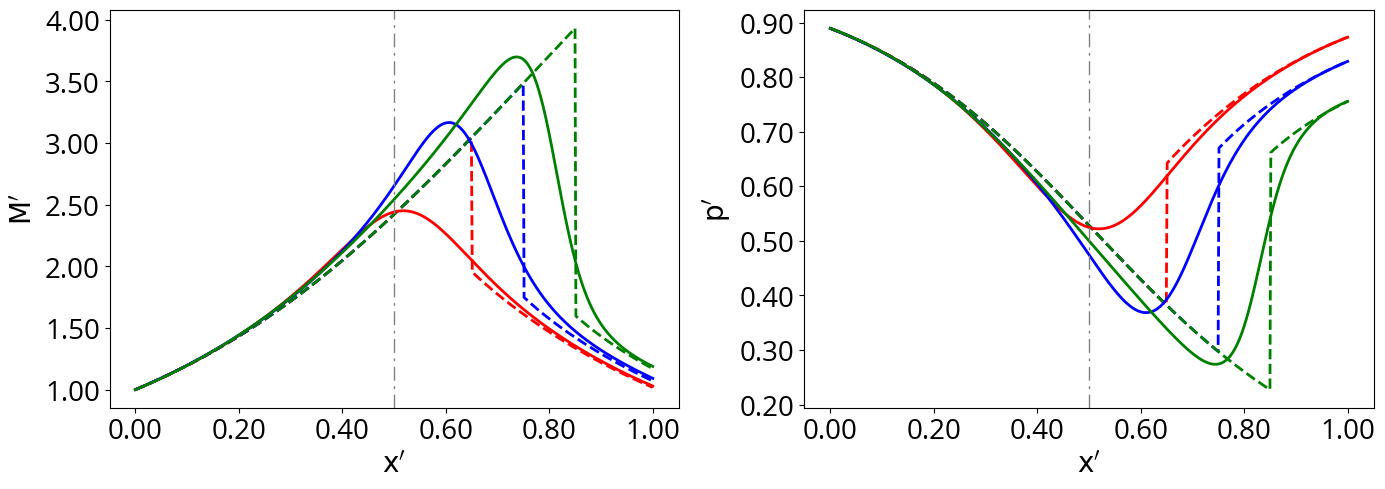

In [14]:
from scipy.optimize import brentq
import matplotlib.ticker as ticker

# ----------------------------------------------------------------------
# 1. Gas properties and nozzle geometry (edit these for your problem)
# ----------------------------------------------------------------------
gamma = 1.4  # ratio of specific heats (1.4 for air)

# Nozzle area distribution A(x)/A_throat, x in arbitrary length units.
# Given directly as A/A* = 1 + 2.2*(x - 0.5)^2  (throat at x = 0.5, length = 1)
x_min, x_throat, x_max = 0.0, 0.5, 1.0


def area_ratio(x):
    """A(x)/A_throat = 1 + 2.2*(x - 0.5)^2."""
    x = np.asarray(x, dtype=float)
    return 1.0 + 2.2 * (x - 0.5) ** 2


# Build analytical references and saved-model predictions for three shock locations.
shock_targets = [0.65, 0.75, 0.85]
shock_targets_all = [0.65, 0.70, 0.75, 0.80, 0.85]
x_shock_target = 0.75
saved_model_dirs = {
    0.65: "SHOCK_SINGLE_065",
    0.70: "SHOCK_SINGLE_070",
    0.75: "SHOCK_SINGLE_075",
    0.80: "SHOCK_SINGLE_080",
    0.85: "SHOCK_SINGLE_085",
}


# ----------------------------------------------------------------------
# 2. Isentropic relations
# ----------------------------------------------------------------------
def area_mach_relation(M, area_ratio_target, gamma=1.4):
    term = (2.0 / (gamma + 1.0)) * (1.0 + 0.5 * (gamma - 1.0) * M**2)
    AoA_star = (1.0 / M) * term ** ((gamma + 1.0) / (2.0 * (gamma - 1.0)))
    return AoA_star - area_ratio_target


def solve_mach_from_area(area_ratio_target, gamma=1.4, subsonic=True):
    if area_ratio_target <= 1.0 + 1e-12:
        return 1.0
    if subsonic:
        lo, hi = 1e-6, 1.0 - 1e-9
    else:
        lo, hi = 1.0 + 1e-9, 60.0
    return brentq(area_mach_relation, lo, hi, args=(area_ratio_target, gamma))


def T0_over_T(M, gamma=1.4):
    return 1.0 + 0.5 * (gamma - 1.0) * M**2


def p_over_p0_isentropic(M, gamma=1.4):
    return T0_over_T(M, gamma) ** (-gamma / (gamma - 1.0))


# ----------------------------------------------------------------------
# 3. Normal shock relations
# ----------------------------------------------------------------------
def normal_shock(M1, gamma=1.4):
    """Given upstream Mach M1 (>1), return M2, p2/p1, rho2/rho1, p02/p01."""
    M2 = np.sqrt(
        (1.0 + 0.5 * (gamma - 1.0) * M1**2) / (gamma * M1**2 - 0.5 * (gamma - 1.0))
    )
    p2_p1 = 1.0 + (2.0 * gamma / (gamma + 1.0)) * (M1**2 - 1.0)
    rho2_rho1 = ((gamma + 1.0) * M1**2) / ((gamma - 1.0) * M1**2 + 2.0)
    p02_p01 = (rho2_rho1 ** (gamma / (gamma - 1.0))) * (
        (gamma + 1.0) / (2.0 * gamma * M1**2 - (gamma - 1.0))
    ) ** (1.0 / (gamma - 1.0))
    return M2, p2_p1, rho2_rho1, p02_p01


# ----------------------------------------------------------------------
# 4. Build solutions along x
# ----------------------------------------------------------------------
n_points = 600
x = np.linspace(x_min, x_max, n_points)
A_ratio_x = area_ratio(x)


def build_analytic_solution(x_shock_loc: float) -> dict[str, np.ndarray | float]:
    A_shock_ratio = area_ratio(np.array([x_shock_loc]))[0]

    M1_at_shock = solve_mach_from_area(A_shock_ratio, gamma, subsonic=False)
    M2_at_shock, _, _, p02_p01 = normal_shock(M1_at_shock, gamma)

    AoAstar_2_at_shock = area_mach_relation(M2_at_shock, 0.0, gamma) + 0.0
    A_star2_over_Astar1 = A_shock_ratio / AoAstar_2_at_shock

    M = np.zeros_like(x)
    p_p0 = np.zeros_like(x)

    for i, xi in enumerate(x):
        Ar = A_ratio_x[i]
        if xi <= x_throat:
            Mi = solve_mach_from_area(Ar, gamma, subsonic=True)
            p_p0[i] = p_over_p0_isentropic(Mi, gamma)
        elif xi <= x_shock_loc:
            Mi = solve_mach_from_area(Ar, gamma, subsonic=False)
            p_p0[i] = p_over_p0_isentropic(Mi, gamma)
        else:
            Ar2 = Ar / A_star2_over_Astar1
            Mi = solve_mach_from_area(Ar2, gamma, subsonic=True)
            p_p0[i] = p_over_p0_isentropic(Mi, gamma) * p02_p01
        M[i] = Mi  # type: ignore

    M0_ref = float(M[0])
    return {
        "x_shock": x_shock_loc,
        "M": M,
        "p_p0": p_p0,
        "M0_ref": M0_ref,
        "M_M0": M / M0_ref,
    }


def latest_checkpoint_path(directory: str) -> str:
    checkpoints = sorted(
        file_name for file_name in os.listdir(directory) if file_name.endswith(".pt")
    )
    if not checkpoints:
        raise FileNotFoundError(f"No checkpoint found in {directory}")
    return os.path.join(directory, checkpoints[-1])


def load_saved_shock_model(directory: str) -> tuple[UnsteadyNet, str]:
    checkpoint_path = latest_checkpoint_path(directory)
    model = UnsteadyNet().to(device)
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model, checkpoint_path


def load_saved_shock_location(directory: str) -> float:
    path = os.path.join(directory, f"{directory}_shock_location.txt")
    with open(path, "r", encoding="utf-8") as file:
        return float(file.read().strip())


def load_saved_history(directory: str) -> np.ndarray:
    path = os.path.join(directory, f"{directory}_history.csv")
    df = pd.read_csv(path)
    return df[["pde_loss", "bc_loss", "total_loss"]].to_numpy()


analytic_solutions = {xs: build_analytic_solution(xs) for xs in shock_targets_all}
ref_solution = analytic_solutions[x_shock_target]
M0_ref = float(ref_solution["M0_ref"])

A = 0.25
half_height = A * (1 + 2.2 * (x - 0.5) ** 2)
y_top = half_height
y_bot = -half_height
wall_thickness = 0.15
wall_fill = "white"
wall_edge = "#001aff"
axis_color = "black"
variant_colors = {
    0.65: "red",
    0.70: "#ff8700",
    0.75: "blue",
    0.80: "purple",
    0.85: "green",
}
prediction_color = "blue"

plt.rcParams["hatch.linewidth"] = 0.5
plt.rcParams["hatch.color"] = "#001aff"


def predict_single_network_solution(
    model: UnsteadyNet,
    n_points: int = EVAL_PRED_POINTS,
    t_eval: float = T_STEADY,
):
    model.eval()
    x = np.linspace(X_START, X_START + X_LENGTH, n_points)
    x_ten = torch.tensor(x, dtype=torch.float32, device=device)[:, None]
    t_ten = torch.full_like(x_ten, t_eval)
    xt = torch.cat([x_ten, t_ten], dim=1)

    with torch.no_grad():
        out = model(xt)
        rho = out[:, 0].cpu().numpy()
        u = out[:, 1].cpu().numpy()
        P = out[:, 2].cpu().numpy()

    M = u / np.sqrt(GAMMA * P / rho)
    return x, M, P


saved_models = {}
saved_predictions = {}
saved_histories = {}
saved_shock_locations = {}
for xs, directory in saved_model_dirs.items():
    model, checkpoint_path = load_saved_shock_model(directory)
    x_pred, M_pred, P_pred = predict_single_network_solution(model)
    saved_models[xs] = {"model": model, "checkpoint_path": checkpoint_path}
    saved_predictions[xs] = {
        "x": x_pred,
        "M": M_pred,
        "P": P_pred,
        "M_M0": M_pred / M0_ref,
    }
    saved_histories[xs] = load_saved_history(directory)
    saved_shock_locations[xs] = load_saved_shock_location(directory)
    print(
        f"Loaded saved model for x_shock={xs:.2f} from {checkpoint_path}; "
        f"detected shock={saved_shock_locations[xs]:.6f}"
    )


# ----------------------------------------------------------------------
# 5. Main comparison plots only
# ----------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.subplots_adjust(wspace=0.35)

line1, line2, line3 = {}, {}, {}
ax = axes[0]
for xs in shock_targets:
    s = analytic_solutions[xs]
    line1 = ax.plot(
        x, s["M_M0"], lw=2, ls="--", color=variant_colors[xs], label=f"Reference"
    )

for xs in shock_targets:
    pred = saved_predictions[xs]
    line2 = ax.plot(
        pred["x"], pred["M_M0"], lw=2, color=variant_colors[xs], label="Prediction"
    )

ax.axvline(x_throat, color="gray", lw=1, linestyle=(0, (10, 4, 2, 4)))
ax.set_xlabel(r"$\text{x}^\prime$", fontsize=20)
ax.set_ylabel(r"$\text{M}^\prime$", fontsize=20, labelpad=5)
# ax.legend(handles=[line2[0], line1[0]], fontsize=12)
ax.tick_params(axis='x', labelsize=20) 
ax.tick_params(axis='y', labelsize=20)
ax.xaxis.set_major_formatter('{x:.2f}')
ax.yaxis.set_major_formatter('{x:.2f}')

ax = axes[1]
for xs in shock_targets:
    s = analytic_solutions[xs]
    line1 = ax.plot(
        x, s["p_p0"], lw=2, ls="--", color=variant_colors[xs], label=f"Reference"
    )

for xs in shock_targets:
    pred = saved_predictions[xs]
    line2 = ax.plot(
        pred["x"], pred["P"], lw=2, color=variant_colors[xs], label=f"Prediction"
    )

ax.axvline(x_throat, color="gray", lw=1, linestyle=(0, (10, 4, 2, 4)))
ax.set_xlabel(r"$\text{x}^\prime$", fontsize=20)
ax.set_ylabel(r"$\text{p}^\prime$", fontsize=20, labelpad=5)
# ax.legend(handles=[line2[0], line1[0]], fontsize=12)
ax.tick_params(axis='x', labelsize=20) 
ax.tick_params(axis='y', labelsize=20)
ax.xaxis.set_major_formatter('{x:.2f}')
ax.yaxis.set_major_formatter('{x:.2f}')
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=8))

plt.tight_layout()
plt.savefig("./nozzle_properties_mach_pressure.svg", format="svg", transparent=True)
plt.show()


def predict_shock_front_and_behind(
    model: UnsteadyNet,
    n_points: int = EVAL_PRED_POINTS,
    t_eval: float = T_STEADY,
) -> tuple[float, float]:
    model.eval()

    x_lin = np.linspace(X_START, X_START + X_LENGTH, n_points)
    x_ten = torch.tensor(x_lin, dtype=torch.float32, device=device)[:, None]
    t_ten = torch.full_like(x_ten, t_eval)
    xt = torch.cat([x_ten, t_ten], dim=1).requires_grad_(True)
    output = model(xt)

    u = output[:, 1]
    du_dx = torch.autograd.grad(u.sum(), xt, create_graph=False)[0][:, 0]
    du_dx_np = du_dx.detach().cpu().numpy()
    du_dx_np[x_lin <= X_THROAT] = 0.0  # mask converging section

    min_idx = int(np.argmin(du_dx_np))
    threshold = SHOCK_FORMATION_TOL * du_dx_np[min_idx]

    # front edge: walk left from the steepest point until slope recovers
    front_idx = min_idx
    for i in range(min_idx, 0, -1):
        if du_dx_np[i] > threshold:
            front_idx = i
            break

    # behind edge: walk right from the steepest point until slope recovers
    behind_idx = min_idx
    for i in range(min_idx, len(du_dx_np)):
        if du_dx_np[i] > threshold:
            behind_idx = i
            break

    x_front = float(np.clip(x_lin[front_idx], X_THROAT, X_START + X_LENGTH))
    x_behind = float(np.clip(x_lin[behind_idx], X_THROAT, X_START + X_LENGTH))
    return x_front, x_behind

import matplotlib.colors as mcolors


def darken(color, factor=0.6):
    """Return a darker version of a matplotlib color."""
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb * factor)


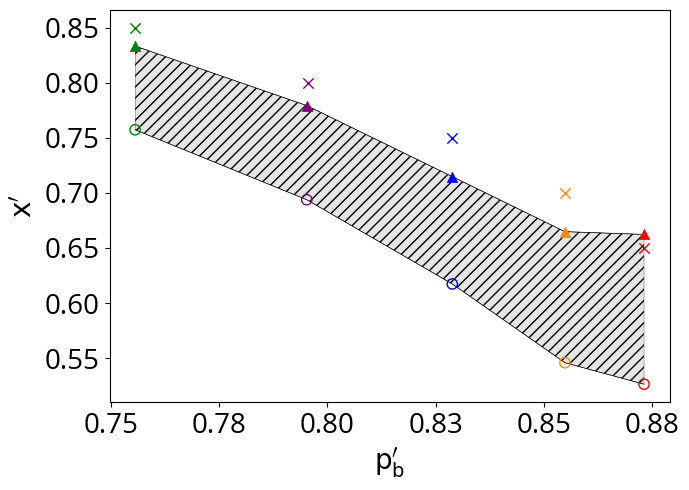

In [21]:
# --- Back-pressure (last) plot, separated into its own figure ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))


front_xs, behind_xs, pb_preds = [], [], []
for xs in shock_targets_all:
    pb_ref = analytic_solutions[xs]["p_p0"][-1]  # type: ignore
    pb_pred = saved_predictions[xs]["P"][-1]

    x_front, x_behind = predict_shock_front_and_behind(saved_models[xs]["model"])
    front_xs.append(x_front)
    behind_xs.append(x_behind)
    pb_preds.append(pb_pred)

    # keep the individual predicted points, colored per shock-target case
    ax.scatter(
        pb_pred,
        x_front,
        s=55,
        facecolors="none",
        edgecolors=variant_colors[xs],
        linewidths=1,
        marker="o",
        zorder=3,
    )
    ax.scatter(
        pb_pred,
        x_behind,
        s=55,
        color=variant_colors[xs],
        marker="^",
        zorder=3,
        linewidths=0.5
    )
    line3 = ax.scatter(
        pb_ref,
        xs,
        s=55,
        color=variant_colors[xs],
        marker="x",
        linewidths=1,
        label="Reference",
    )

# sort by back-pressure so the connecting lines / shaded band are well-ordered
order = np.argsort(pb_preds)
pb_sorted = np.array(pb_preds)[order]
front_sorted = np.array(front_xs)[order]
behind_sorted = np.array(behind_xs)[order]

(line_front,) = ax.plot(
    pb_sorted,
    front_sorted,
    color="black",
    lw=0.5,
    zorder=2,
    label="Predicted (rise)",
)
(line_behind,) = ax.plot(
    pb_sorted,
    behind_sorted,
    color="black",
    lw=0.5,
    zorder=2,
    label="Predicted (fall)",
)
ax.fill_between(
    pb_sorted,
    front_sorted,
    behind_sorted,
    facecolor=mcolors.to_rgba("black", alpha=0.1),  # low-alpha fill
    edgecolor=darken("black", factor=0.4),
    hatch="///",
    linewidth=0.2,
)

# ax.set_xlim(x_throat, x_max)
ax.set_xlabel(r"$\text{p}_\text{b}^\prime$", fontsize=20)
ax.set_ylabel(r"$\text{x}^\prime$", fontsize=20, labelpad=5)
# ax.legend(handles=[line_front, line_behind, line3], fontsize=12)
ax.tick_params(axis='x', labelsize=20) 
ax.tick_params(axis='y', labelsize=20)
ax.xaxis.set_major_formatter('{x:.2f}')
ax.yaxis.set_major_formatter('{x:.2f}')
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=8))

plt.tight_layout()
plt.savefig("./nozzle_back_pressure.svg", format="svg", transparent=True)
plt.show()

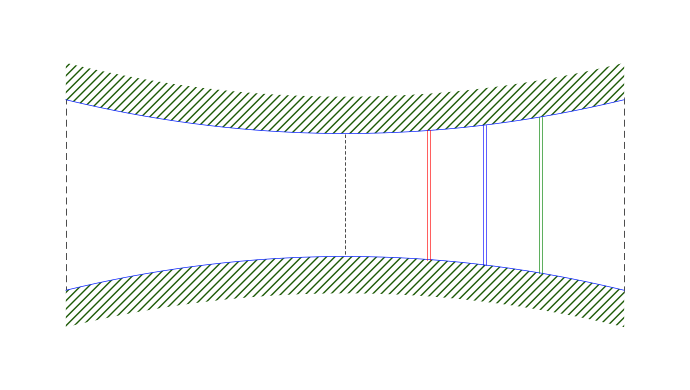

In [24]:
# --- Nozzle-only figure ---
fig, ax = plt.subplots(1, 1, figsize=(7, 4))


ax.fill_between(
    x,
    y_top,
    y_top + wall_thickness,
    facecolor=wall_fill,
    edgecolor="#1c5a05",
    hatch="////",
    linewidth=0.0,
    zorder=2,
)
ax.fill_between(
    x,
    y_bot - wall_thickness,
    y_bot,
    facecolor=wall_fill,
    edgecolor="#1c5a05",
    hatch="////",
    linewidth=0.0,
    zorder=2,
)

ax.plot(x, y_top, color=wall_edge, linewidth=0.5, zorder=3)
ax.plot(x, y_bot, color=wall_edge, linewidth=0.5, zorder=3)

ax.plot(
    [0.5, 0.5],
    [A, -A],
    color=axis_color,
    linestyle="--",
    linewidth=0.5,
    dashes=(5, 3),
    zorder=1,
)

ax.plot(
    [0.0, 0.0],
    [A + wall_thickness, -A - wall_thickness],
    color=axis_color,
    linewidth=0.5,
    zorder=1,
    linestyle="--",
    dashes=(10, 6),
)
ax.plot(
    [1.0, 1.0],
    [A + wall_thickness, -A - wall_thickness],
    color=axis_color,
    linewidth=0.5,
    zorder=1,
    linestyle="--",
    dashes=(10, 6),
)

shock_dx = 0.0025
for xs in shock_targets:
    shock_half = A * (1 + 2.2 * (xs - 0.5) ** 2)
    c = variant_colors[xs]
    ax.plot(
        [xs - shock_dx, xs - shock_dx],
        [-shock_half, shock_half],
        color=c,
        linewidth=0.45,
        zorder=4,
    )
    ax.plot(
        [xs + shock_dx, xs + shock_dx],
        [-shock_half, shock_half],
        color=c,
        linewidth=0.45,
        zorder=4,
    )

# for xs in shock_targets:
#     shock_loc = saved_shock_locations[xs]
#     shock_half = A * (1 + 2.2 * (shock_loc - 0.5) ** 2)
#     ax.plot(
#         [shock_loc, shock_loc],
#         [-shock_half, shock_half],
#         color=variant_colors[xs],
#         linewidth=1.2,
#         linestyle="--",
#         zorder=5,
#     )
    # ax.text(
    #     shock_loc,
    #     shock_half + 0.04,
    #     f"x_shock={xs:.2f}",
    #     color=variant_colors[xs],
    #     ha="center",
    #     va="bottom",
    #     fontsize=8,
    # )

x_min_profile, x_max_profile = X_START, X_START + X_LENGTH
y_min_profile = np.min(y_bot - wall_thickness)
y_max_profile = np.max(y_top + wall_thickness)
x_margin = 0.10 * (x_max_profile - x_min_profile)
y_margin = 0.20 * (y_max_profile - y_min_profile)
ax.set_xlim(x_min_profile - x_margin, x_max_profile + x_margin)
ax.set_ylim(y_min_profile - y_margin, y_max_profile + y_margin)
ax.axis("off")

plt.tight_layout()
plt.savefig("./nozzle_geometry.svg", format="svg", transparent=True)
plt.show()

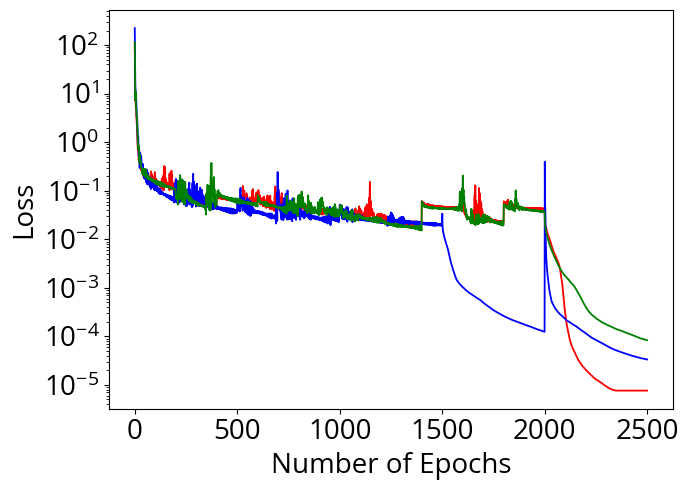

In [16]:
# --- Loss-only figure ---
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

for xs in shock_targets:
    history = saved_histories[xs]
    color = variant_colors[xs]
    epochs = np.arange(history.shape[0])
    ax.semilogy(epochs, history[:, 2], color=color, lw=1.3, label=f"x_shock={xs:.2f}")
    # ax.semilogy(epochs, history[:, 0], color=color, lw=1.1, ls="--")
    # ax.semilogy(epochs, history[:, 1], color=color, lw=1.1, ls="-.")

ax.set_xlabel("Number of Epochs", fontsize=20)
ax.set_ylabel("Loss", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# ax.legend(fontsize=11)
ax.grid(False)

plt.tight_layout()
plt.savefig("./nozzle_loss_history.svg", format="svg", transparent=True)
plt.show()

In [27]:
class ShockParam(nn.Module):
    def __init__(self, x: float):
        super().__init__()
        self.x_shock = nn.Parameter(torch.tensor([x], device=device))

    def clamped_x(self) -> torch.Tensor:
        return self.x_shock.clamp(X_THROAT + BD_DELTA, X_START + X_LENGTH - BD_DELTA)


class DualUnsteadyLoss:
    @staticmethod
    def _pde_single(model: UnsteadyNet, xt: torch.Tensor):
        return UnsteadyLoss.pde(model, xt)

    @staticmethod
    def _left_bc(model: UnsteadyNet, xt: torch.Tensor):
        return UnsteadyLoss.bc(model, xt)

    @staticmethod
    def _right_bc(model: UnsteadyNet, xt: torch.Tensor):
        return UnsteadyLoss.bc(model, xt)

    @staticmethod
    def interface(
        shock: ShockParam,
        net_L: UnsteadyNet,
        net_R: UnsteadyNet,
        t_pts: torch.Tensor,
    ):
        """
        moving shock with speed W = dx_s/dt:
            + rho_L*(u_L - W) = rho_R*(u_R - W)
            + rho_L*(u_L-W)^2 + P_L = rho_R*(u_R-W)^2 + P_R
            + H_L + (u_L-W)^2/2 = H_R + (u_R-W)^2/2
            - u_R > a_R
            - u_L < a_L
            - P_R < P_L
        """
        x_s = shock.clamped_x()
        x_col = x_s.expand(t_pts.shape[0]).unsqueeze(1)
        t_col = t_pts.unsqueeze(1)
        xt_i = torch.cat([x_col, t_col], dim=1)

        out_L = net_L(xt_i)
        out_R = net_R(xt_i)
        rho_L, u_L, P_L = out_L[:, 0], out_L[:, 1], out_L[:, 2]
        rho_R, u_R, P_R = out_R[:, 0], out_R[:, 1], out_R[:, 2]
        A_i = get_area(x_s).expand_as(rho_L)

        H_L = GAMMA / (GAMMA - 1.0) * P_L / (rho_L + BD_DELTA)
        H_R = GAMMA / (GAMMA - 1.0) * P_R / (rho_R + BD_DELTA)

        flux_L_mass = rho_L * u_L * A_i
        flux_R_mass = rho_R * u_R * A_i
        rh_mass = (flux_L_mass - flux_R_mass).pow(2).mean()

        flux_L_mom = (rho_L * u_L**2 + P_L) * A_i
        flux_R_mom = (rho_R * u_R**2 + P_R) * A_i
        rh_mom = (flux_L_mom - flux_R_mom).pow(2).mean()

        flux_L_en = rho_L * u_L * (H_L + 0.5 * u_L**2) * A_i
        flux_R_en = rho_R * u_R * (H_R + 0.5 * u_R**2) * A_i
        rh_en = (flux_L_en - flux_R_en).pow(2).mean()

        a_L = torch.sqrt(GAMMA * P_L / (rho_L + BD_DELTA) + BD_DELTA)
        a_R = torch.sqrt(GAMMA * P_R / (rho_R + BD_DELTA) + BD_DELTA)
        sup_pre = torch.relu(a_L - u_L).pow(2).mean()
        sub_post = torch.relu(u_R - a_R).pow(2).mean()
        entropy = torch.relu(P_L - P_R).pow(2).mean()

        return rh_mass + rh_mom + rh_en + sup_pre + sub_post + entropy


print("DualUnsteadyLoss defined.")

DualUnsteadyLoss defined.


In [18]:
def dual_network_training_loop(last_x_shock: float):
    net_L = UnsteadyNet().to(device)
    net_R = UnsteadyNet().to(device)

    net_L.load_state_dict(shock_detection_model.state_dict())
    net_R.load_state_dict(shock_detection_model.state_dict())

    shock = ShockParam(last_x_shock).to(device)

    pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
    pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

    best_L, snap_L = float("inf"), {}
    best_R, snap_R = float("inf"), {}
    best_I, snap_I = float("inf"), {}
    loss_history = []

    # ── Adam fine-tune ────────────────────────────────────────────────────
    model_params = list(net_L.parameters()) + list(net_R.parameters())
    model_opt = torch.optim.Adam(model_params, lr=DUAL_NET_ADAM_LR)
    shock_opt = torch.optim.Adam(shock.parameters(), lr=DUAL_NET_SHOCK_LR)
    print(f"Dual network Adam phase ({DUAL_NET_ADAM_EPOCHS} epochs)…")

    for epoch in range(DUAL_NET_ADAM_EPOCHS):
        if epoch % DUAL_NET_RESAMPLE_EVERY == 0:
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

        if epoch % REMESH_EVERY == 0 and epoch > 0:
            new_xs = shock.clamped_x().item()
            if abs(new_xs - last_x_shock) > REMESH_SHIFT_TOL:
                last_x_shock = new_xs
                pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
                pts_R = sample_points(
                    last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS
                )
                print(f"  Remesh at epoch {epoch}: x_shock = {last_x_shock:.6f}")

        t_interface = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
        interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior = (shock.clamped_x() - X_SHOCK_REF) ** 2

        pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L).pow(2).mean()
        pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R).pow(2).mean()

        bc_L = DualUnsteadyLoss._left_bc(net_L, pts_L)
        bc_R = DualUnsteadyLoss._right_bc(net_R, pts_R)

        loss = (
            pde_L
            + pde_R
            + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
            + DUAL_NET_INTERFACE_WEIGHT * interface
            + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
        )

        if not torch.isfinite(loss):
            if snap_L:
                net_L.load_state_dict(snap_L)
            if snap_R:
                net_R.load_state_dict(snap_R)
            if snap_I:
                shock.load_state_dict(snap_I)
            print(f"  NaN at epoch {epoch} — restored best snapshot, continuing")
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
            continue

        model_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model_params, DUAL_NET_GRAD_CLIP)
        for p in shock.parameters():
            p.grad = None
        model_opt.step()

        shock_opt.zero_grad()
        interface2 = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior2 = DUAL_NET_SHOCK_PRIOR_WEIGHT * (shock.clamped_x() - X_SHOCK_REF) ** 2
        shock_loss = DUAL_NET_INTERFACE_WEIGHT * interface2 + prior2
        shock_loss.backward()
        shock_opt.step()

        loss_history.append(
            (
                loss.item(),
                pde_L.item(),
                pde_R.item(),
                bc_L.item(),
                bc_R.item(),
                interface.item(),
                shock.clamped_x().item(),
            )
        )

        best_L, snap_L = ModelHandler.update_best(net_L, loss.item(), best_L, snap_L)
        best_R, snap_R = ModelHandler.update_best(net_R, loss.item(), best_R, snap_R)
        best_I, snap_I = ModelHandler.update_best(shock, loss.item(), best_I, snap_I)

        if (epoch + 1) % DUAL_NET_PRINT_EVERY == 0:
            xs = shock.clamped_x().item()
            with torch.no_grad():
                xt_s = torch.tensor([[xs, T_STEADY]], device=device)
                o_L = net_L(xt_s)
                o_R = net_R(xt_s)
                M_L = (o_L[0, 1] / torch.sqrt(GAMMA * o_L[0, 2] / o_L[0, 0])).item()
                M_R = (o_R[0, 1] / torch.sqrt(GAMMA * o_R[0, 2] / o_R[0, 0])).item()
            print(
                f"  epoch {epoch+1}/{DUAL_NET_ADAM_EPOCHS}  x_shock={xs:.5f}  "
                f"loss={loss.item():.4e}  "
                f"pde=({pde_L.item():.3e},{pde_R.item():.3e})  "
                f"bc=({bc_L.item():.3e},{bc_R.item():.3e})  "
                f"interface={interface.item():.3e}  "
                f"M@shock: pre={M_L:.3f}(>1) post={M_R:.3f}(<1)"
            )

    net_L.load_state_dict(snap_L)
    net_R.load_state_dict(snap_R)
    shock.load_state_dict(snap_I)

    # ── L-BFGS fine-tune ──────────────────────────────────────────────────
    print("Dual network L-BFGS phase…")
    all_lbfgs_params = (
        list(net_L.parameters()) + list(net_R.parameters()) + list(shock.parameters())
    )
    last = {"nan": False}

    def mk_closure(optim, pts_L_lbfgs, pts_R_lbfgs, t_interface_lbfgs):
        def closure_dual():
            optim.zero_grad()
            pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L_lbfgs).pow(2).mean()
            pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R_lbfgs).pow(2).mean()

            bc_L = DualUnsteadyLoss._left_bc(net_L, pts_L_lbfgs)
            bc_R = DualUnsteadyLoss._right_bc(net_R, pts_R_lbfgs)

            interface = DualUnsteadyLoss.interface(
                shock, net_L, net_R, t_interface_lbfgs
            )
            prior = (shock.clamped_x() - X_SHOCK_REF) ** 2

            loss = (
                pde_L
                + pde_R
                + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
                + DUAL_NET_INTERFACE_WEIGHT * interface
                + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
            )

            if not torch.isfinite(loss):
                last["nan"] = True
                return loss

            loss.backward()
            nn.utils.clip_grad_norm_(all_lbfgs_params, DUAL_NET_GRAD_CLIP)  # NEW
            last["nan"] = False
            loss_data = (
                loss.item(),
                pde_L.item(),
                pde_R.item(),
                bc_L.item(),
                bc_R.item(),
                interface.item(),
                shock.clamped_x().item(),
            )

            last["loss"] = loss_data  # type: ignore
            return loss

        return closure_dual

    epoch = 0
    consecutive_nan = 0
    lbfgs = torch.optim.LBFGS(
        all_lbfgs_params,
        line_search_fn="strong_wolfe",
        lr=0.5 if consecutive_nan == 0 else 0.5 * (0.5**consecutive_nan),
    )

    while epoch < DUAL_NET_LBFGS_EPOCHS:
        pts_L_lbfgs = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
        pts_R_lbfgs = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
        t_interface_lbfgs = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX

        closure = mk_closure(lbfgs, pts_L_lbfgs, pts_R_lbfgs, t_interface_lbfgs)
        chunk_end = min(epoch + DUAL_NET_LBFGS_RESAMPLE_EVERY, DUAL_NET_LBFGS_EPOCHS)

        for _ in range(epoch, chunk_end):
            lbfgs.step(closure)
            epoch += 1

            if last["nan"]:
                net_L.load_state_dict(snap_L)
                net_R.load_state_dict(snap_R)
                shock.load_state_dict(snap_I)
                consecutive_nan += 1

                lbfgs = torch.optim.LBFGS(
                    all_lbfgs_params,
                    line_search_fn="strong_wolfe",
                    lr=0.5 if consecutive_nan == 0 else 0.5 * (0.5**consecutive_nan),
                )
                print(f"  epoch {epoch}: non-finite loss (attempt {consecutive_nan})")
                break

            consecutive_nan = 0
            loss_history.append(last["loss"])
            best_L, snap_L = ModelHandler.update_best(
                net_L, last["loss"][0], best_L, snap_L  # type: ignore
            )
            best_R, snap_R = ModelHandler.update_best(
                net_R, last["loss"][0], best_R, snap_R  # type: ignore
            )
            best_I, snap_I = ModelHandler.update_best(
                shock, last["loss"][0], best_I, snap_I  # type: ignore
            )

            if (epoch + 1) % max(1, DUAL_NET_PRINT_EVERY // 10) == 0:
                xs = shock.clamped_x().item()
                with torch.no_grad():
                    xt_s = torch.tensor([[xs, T_STEADY]], device=device)
                    o_L, o_R = net_L(xt_s), net_R(xt_s)
                    M_L = (o_L[0, 1] / torch.sqrt(GAMMA * o_L[0, 2] / o_L[0, 0])).item()
                    M_R = (o_R[0, 1] / torch.sqrt(GAMMA * o_R[0, 2] / o_R[0, 0])).item()
                print(
                    f"  epoch {epoch+1}/{DUAL_NET_LBFGS_EPOCHS}  x_shock={xs:.5f}  "
                    f"loss={last['loss'][0]:.4e}  "  # type: ignore
                    f"pde=({last['loss'][1]:.3e},{last['loss'][2]:.3e})  "  # type: ignore
                    f"bc=({last['loss'][3]:.3e},{last['loss'][4]:.3e})  "  # type: ignore
                    f"interface={last['loss'][5]:.3e}  "  # type: ignore
                    f"M@shock: pre={M_L:.3f}(>1) post={M_R:.3f}(<1)"
                )

        if consecutive_nan >= DUAL_MAX_CONSECUTIVE_NAN:
            print(
                f"  L-BFGS phase aborted at epoch {epoch}: {DUAL_MAX_CONSECUTIVE_NAN} consecutive non-finite steps."
            )
            break

    path_L = ModelHandler.save_path(DUAL_NET_PRE_MODEL_NAME)
    path_R = ModelHandler.save_path(DUAL_NET_POST_MODEL_NAME)
    path_I = ModelHandler.save_path(INTERFACE_MODEL_NAME)
    ModelHandler.save(net_L, path_L)
    ModelHandler.save(net_R, path_R)
    ModelHandler.save(shock, path_I)

    return net_L, net_R, shock, loss_history, (path_L, path_R, path_I)


pre_shock_model, post_shock_model, shock_param, dual_loss_history, model_paths = (
    dual_network_training_loop(last_x_shock=x_shock)
)

Dual network Adam phase (6000 epochs)…
  epoch 500/6000  x_shock=0.63352  loss=1.7572e-01  pde=(2.247e-02,1.476e-02)  bc=(3.193e-04,3.431e-04)  interface=6.397e-03  M@shock: pre=2.560(>1) post=0.504(<1)
  Remesh at epoch 600: x_shock = 0.637817
  epoch 1000/6000  x_shock=0.65322  loss=2.9452e-01  pde=(1.368e-02,2.568e-02)  bc=(6.101e-04,4.672e-04)  interface=1.975e-02  M@shock: pre=2.559(>1) post=0.506(<1)
  Remesh at epoch 1200: x_shock = 0.661127
  epoch 1500/6000  x_shock=0.67248  loss=1.7189e-01  pde=(1.403e-02,2.574e-02)  bc=(4.957e-03,5.153e-04)  interface=4.732e-03  M@shock: pre=2.666(>1) post=0.501(<1)
  Remesh at epoch 1800: x_shock = 0.684409
  epoch 2000/6000  x_shock=0.69220  loss=1.1917e-01  pde=(1.625e-02,1.261e-02)  bc=(3.647e-04,2.451e-04)  interface=6.748e-03  M@shock: pre=2.679(>1) post=0.497(<1)
  Remesh at epoch 2400: x_shock = 0.707899
  epoch 2500/6000  x_shock=0.70848  loss=2.0358e-01  pde=(1.071e-02,3.390e-02)  bc=(4.755e-03,1.102e-03)  interface=9.177e-03  M@sh

In [34]:
def predict_final_results():
    pre_shock_model.eval()
    post_shock_model.eval()
    shock_param.eval()

    shock_at = shock_param.clamped_x().item()
    print(f"\nFinal shock location: {shock_at:.6f}  (reference: {X_SHOCK_REF:.4f})")

    x_eval_np = np.linspace(X_START, X_START + X_LENGTH, EVAL_PRED_POINTS)
    x_ten = torch.tensor(x_eval_np, dtype=torch.float32, device=device)
    t_ten = torch.full_like(x_ten, T_STEADY)
    xt_eval = torch.stack([x_ten, t_ten], dim=1)

    with torch.no_grad():
        out_pre = pre_shock_model(xt_eval[x_eval_np < shock_at])  # type: ignore
        out_post = post_shock_model(xt_eval[x_eval_np >= shock_at])  # type: ignore

    rho_pre, u_pre, P_pre, T_pre = (
        out_pre[:, 0].cpu().numpy(),
        out_pre[:, 1].cpu().numpy(),
        out_pre[:, 2].cpu().numpy(),
        out_pre[:, 3].cpu().numpy(),
    )
    rho_post, u_post, P_post, T_post = (
        out_post[:, 0].cpu().numpy(),
        out_post[:, 1].cpu().numpy(),
        out_post[:, 2].cpu().numpy(),
        out_post[:, 3].cpu().numpy(),
    )

    M_pre = u_pre / np.sqrt(GAMMA * P_pre / rho_pre)
    M_post = u_post / np.sqrt(GAMMA * P_post / rho_post)

    print(f"M at shock (pre) : {M_pre[-1]:.4f}  (expect >1)")
    print(f"M at shock (post): {M_post[0]:.4f}  (expect <1)")
    print(f"P at exit        : {P_post[-1]:.4f}  (target {P_EXIT:.4f})")

    return (
        x_eval_np,
        (rho_pre, u_pre, P_pre, T_pre, M_pre),
        (rho_post, u_post, P_post, T_post, M_post),
        shock_at,
    )


x_eval_np, pre_results, post_results, final_shock_loc = predict_final_results()


Final shock location: 0.750091  (reference: 0.9000)
M at shock (pre) : 1.4581  (expect >1)
M at shock (post): 0.7165  (expect <1)
P at exit        : 0.8286  (target 0.7101)


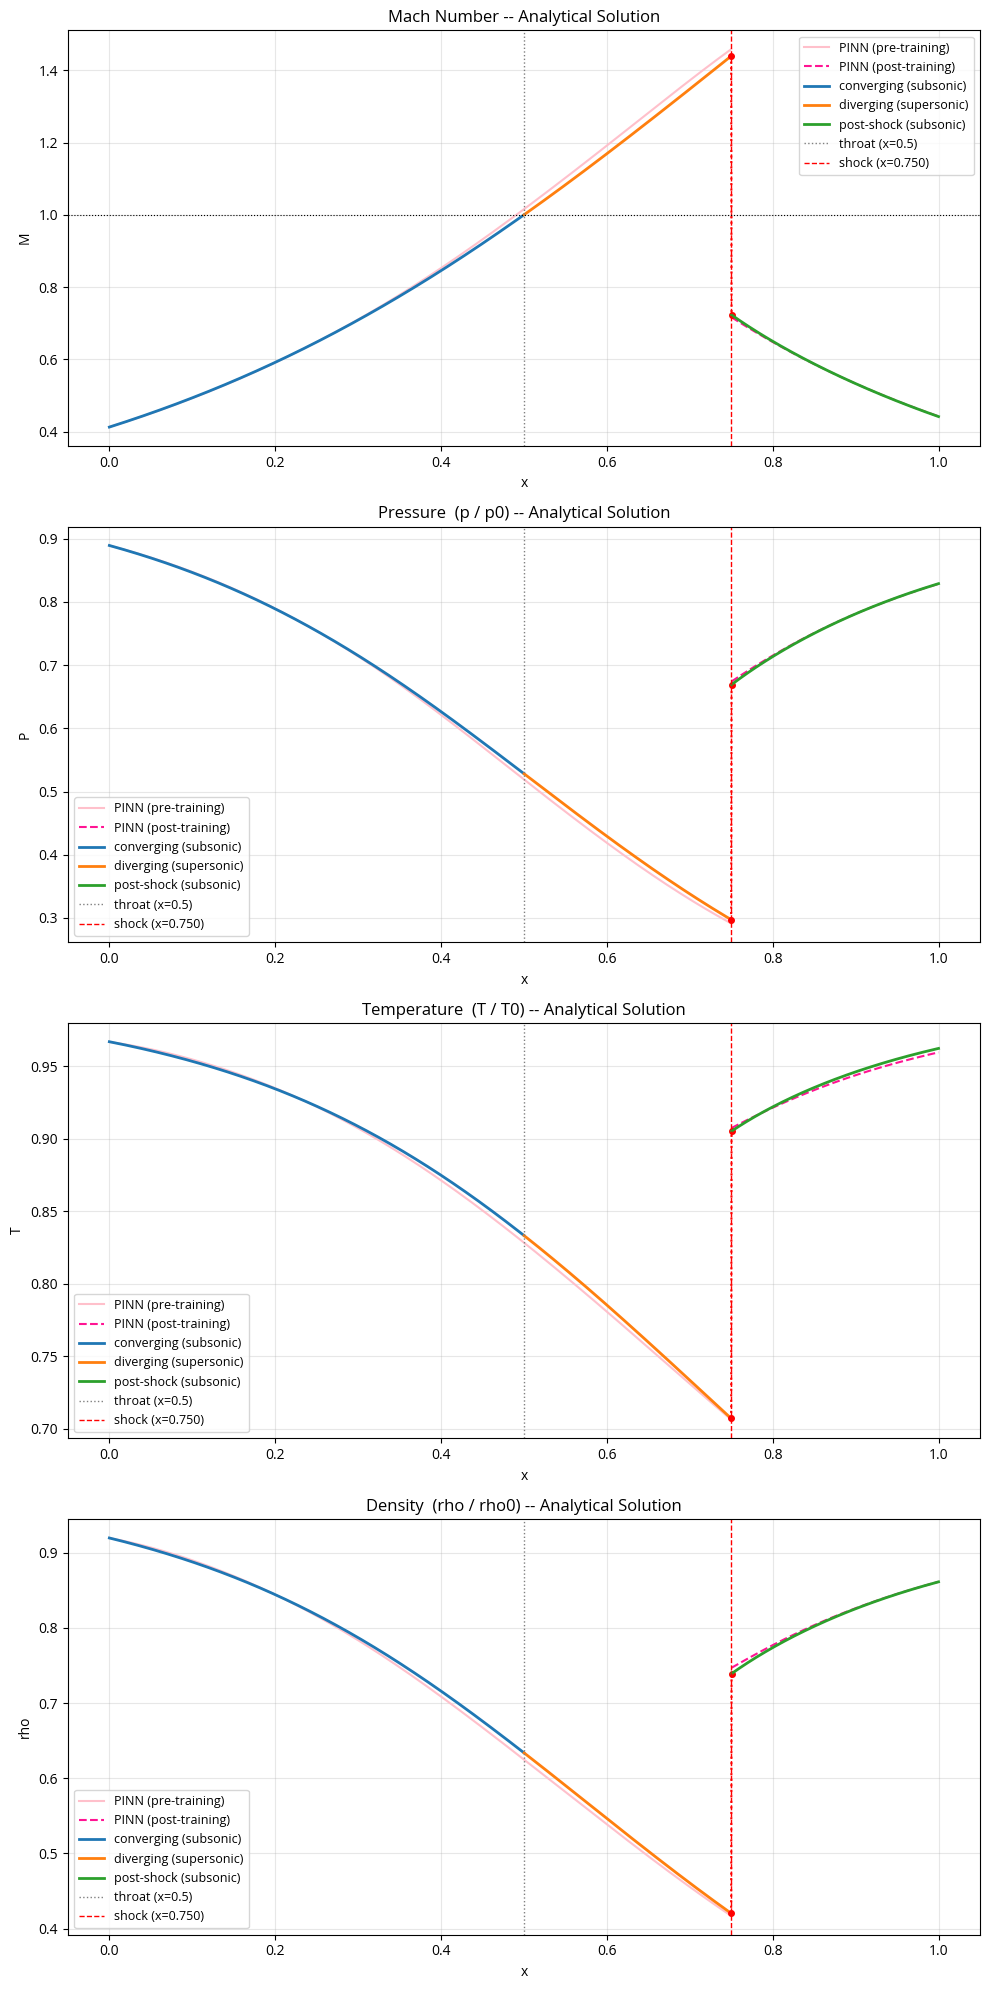

Shock at x = 0.7500
M:   1.4393 (pre-shock)  ->  0.7237 (post-shock)
P0 ratio across shock (p02/p01): 0.9478
Exit conditions: M=0.4419  P=0.8289  T=0.9624  rho=0.8613
Done.


In [20]:
fig, axes = plt.subplots(4, 1, figsize=(10, 20))

x_sub, (M_sub, P_sub, T_sub, rho_sub) = analytic.data("subsonic")
x_sup, (M_sup, P_sup, T_sup, rho_sup) = analytic.data("supersonic")
x_post, (M_post, P_post, T_post, rho_post) = analytic.data("post-shock")

panels = [
    ("Mach Number", "M", (M_sub, M_sup, M_post), [pre_results[4], post_results[4]]),
    ("Pressure  (p / p0)", "P", (P_sub, P_sup, P_post), [pre_results[2], post_results[2]]),
    ("Temperature  (T / T0)", "T", (T_sub, T_sup, T_post), [pre_results[3], post_results[3]]),
    ("Density  (rho / rho0)", "rho", (rho_sub, rho_sup, rho_post), [pre_results[0], post_results[0]]),
]



for ax, (title, ylabel, analytical, pinn) in zip(axes, panels):
    pinn_pre, pinn_post = pinn
    x_pinn_pre = x_eval_np[x_eval_np < final_shock_loc]
    x_pinn_post = x_eval_np[x_eval_np >= final_shock_loc]
    ax.plot(x_pinn_pre, pinn_pre, color="pink", label="PINN (pre-training)")
    ax.plot(x_pinn_post, pinn_post, color="deeppink", ls="--", label="PINN (post-training)")

    y_sub, y_sup, y_post = analytical
    ax.plot(x_sub, y_sub, color="tab:blue", lw=2, label="converging (subsonic)")
    ax.plot(x_sup, y_sup, color="tab:orange", lw=2, label="diverging (supersonic)")
    ax.plot(
        [x_sup[-1], x_post[0]], [y_sup[-1], y_post[0]],
        color="red", lw=1.5, ls=":", marker="o", ms=4,
    )

    ax.plot(x_post, y_post, color="tab:green", lw=2, label="post-shock (subsonic)")

    ax.axvline(X_THROAT, color="gray", ls=":", lw=1, label=f"throat (x={X_THROAT})")
    ax.axvline(
        analytic.x_shock, color="red", ls="--", lw=1,
        label=f"shock (x={analytic.x_shock:.3f})",
    )
    if title == "Mach Number":
        ax.axhline(1.0, color="black", ls=":", lw=0.8)

    ax.set_title(f"{title} -- Analytical Solution")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("x")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cd_nozzle_analytical_results.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Shock at x = {analytic.x_shock:.4f}")
print(f"M:   {analytic.M1:.4f} (pre-shock)  ->  {analytic.M2:.4f} (post-shock)")
print(f"P0 ratio across shock (p02/p01): {analytic.p02_by_p01:.4f}")
print(f"Exit conditions: M={M_post[-1]:.4f}  P={P_post[-1]:.4f}  T={T_post[-1]:.4f}  rho={rho_post[-1]:.4f}")
print("Done.")

In [21]:
def save_data_from_dual_network(
    net_L: UnsteadyNet,
    net_R: UnsteadyNet,
    shock_param: ShockParam,
    loss_history: list[tuple[float, float, float, float, float, float, float]],
    model_paths: tuple[str, str, str],
):
    path_L, path_R, path_I = model_paths
    dir_path = path_L.rsplit("/", 1)[0]
    os.makedirs(dir_path, exist_ok=True)

    df = pd.DataFrame(
        loss_history,
        columns=[
            "total_loss",
            "pde_L",
            "pde_R",
            "bc_L",
            "bc_R",
            "interface_loss",
            "shock_location",
        ],
    )
    df.to_csv(os.path.join(dir_path, f"dual_network_history.csv"), index=False)
    print(f"  Saved dual network training history to dual_network_history.csv")

    with open(os.path.join(dir_path, f"dual_network_shock_location.txt"), "w") as f:
        f.write(f"{shock_param.clamped_x().item():.6f}\n")
    print(f"  Saved final shock location to dual_network_shock_location.txt")

    ModelHandler.save(net_L, path_L)
    ModelHandler.save(net_R, path_R)
    ModelHandler.save(shock_param, path_I)
    print(f"  Saved pre-shock model to {path_L}")
    print(f"  Saved post-shock model to {path_R}")
    print(f"  Saved shock parameter model to {path_I}")


save_data_from_dual_network(
    pre_shock_model,
    post_shock_model,
    shock_param,
    dual_loss_history,
    (
        "DUAL_NET_UNVARIANT/pre_shock_model.pt",
        "DUAL_NET_UNVARIANT/post_shock_model.pt",
        "DUAL_NET_UNVARIANT/shock_param_model.pt",
    ),
)

  Saved dual network training history to dual_network_history.csv
  Saved final shock location to dual_network_shock_location.txt
  Saved: DUAL_NET_UNVARIANT/pre_shock_model.pt
  Saved: DUAL_NET_UNVARIANT/post_shock_model.pt
  Saved: DUAL_NET_UNVARIANT/shock_param_model.pt
  Saved pre-shock model to DUAL_NET_UNVARIANT/pre_shock_model.pt
  Saved post-shock model to DUAL_NET_UNVARIANT/post_shock_model.pt
  Saved shock parameter model to DUAL_NET_UNVARIANT/shock_param_model.pt


In [33]:
# load dual network models and shock parameter for evaluation
pre_shock_model = UnsteadyNet().to(device)
post_shock_model = UnsteadyNet().to(device)
pre_shock_model.load_state_dict(torch.load("DUAL_NET_UNVARIANT/pre_shock_model.pt", map_location=device))
post_shock_model.load_state_dict(torch.load("DUAL_NET_UNVARIANT/post_shock_model.pt", map_location=device))
shock_param = ShockParam(0.0).to(device)
shock_param.load_state_dict(torch.load("DUAL_NET_UNVARIANT/shock_param_model.pt", map_location=device))

<All keys matched successfully>

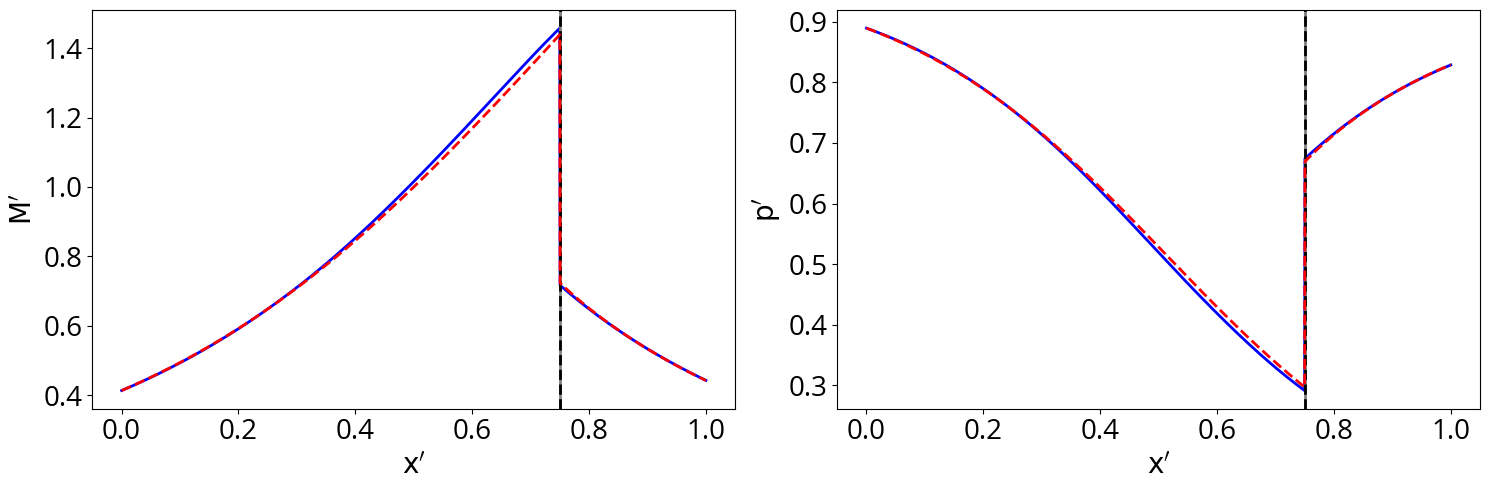

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x_sub, (M_sub, P_sub, T_sub, rho_sub) = analytic.data("subsonic")
x_sup, (M_sup, P_sup, T_sup, rho_sup) = analytic.data("supersonic")
x_post, (M_post, P_post, T_post, rho_post) = analytic.data("post-shock")

x_ref = np.concatenate([x_sub, x_sup, x_post])
M_ref = np.concatenate([M_sub, M_sup, M_post])
P_ref = np.concatenate([P_sub, P_sup, P_post])

x_pinn = np.concatenate(
    [x_eval_np[x_eval_np < final_shock_loc], x_eval_np[x_eval_np >= final_shock_loc]]
)
M_pinn = np.concatenate([pre_results[4], post_results[4]])
P_pinn = np.concatenate([pre_results[2], post_results[2]])

panels = [
    (axes[0], M_ref, M_pinn, r"$\text{M}^\prime$"),
    (axes[1], P_ref, P_pinn, r"$\text{p}^\prime$"),
]

for ax, y_ref, y_pinn, ylabel in panels:
    ax.plot(x_pinn, y_pinn, color="blue", lw=2, zorder=2)
    ax.plot(x_ref, y_ref, color="red", ls="--", lw=2, zorder=3)
    ax.axvline(final_shock_loc, color="gray", lw=2)
    ax.axvline(0.75, color="black", lw=2, ls="--")
    ax.set_xlabel(r"$\text{x}^\prime$", fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=20)
    ax.grid(False)

plt.tight_layout()
plt.savefig("cd_nozzle_M_P_results.svg", format="svg", transparent=True)
plt.show()

In [23]:
# fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# sd = np.array(shock_det_history)
# axes[0].semilogy(sd[:, 2], color="black",      lw=1.5, label="Total")
# axes[0].semilogy(sd[:, 0], color="tab:blue",   lw=1,   label="PDE", alpha=0.8)
# axes[0].semilogy(sd[:, 1], color="tab:orange", lw=1,   label="BC",  alpha=0.8)
# axes[0].set_title("Shock-Detection Model — Loss vs Epoch")
# axes[0].set_xlabel("Epoch")
# axes[0].set_ylabel("Loss (log scale)")
# axes[0].legend()
# axes[0].grid(True, which="both", alpha=0.3)

# dl = np.array(dual_loss_history)
# axes[1].semilogy(dl[:, 0], color="black",      lw=1.5, label="Total")
# axes[1].semilogy(dl[:, 1], color="tab:blue",   lw=1,   label="PDE (pre-shock)",  alpha=0.8)
# axes[1].semilogy(dl[:, 2], color="tab:orange", lw=1,   label="PDE (post-shock)", alpha=0.8)
# axes[1].semilogy(dl[:, 3], color="tab:green",  lw=1,   label="BC (pre-shock)",   alpha=0.8)
# axes[1].semilogy(dl[:, 4], color="tab:red",    lw=1,   label="BC (post-shock)",  alpha=0.8)
# axes[1].semilogy(dl[:, 5], color="purple",     lw=1,   label="Interface",        alpha=0.8)
# axes[1].set_title("Dual-Network Model — Loss vs Epoch")
# axes[1].set_xlabel("Epoch")
# axes[1].set_ylabel("Loss (log scale)")
# axes[1].legend()
# axes[1].grid(True, which="both", alpha=0.3)

# plt.tight_layout()
# plt.savefig("loss_history.png", dpi=150, bbox_inches="tight")
# plt.show()

In [35]:
# load single shock model loss history
shock_det_history = np.loadtxt("SHOCK_SINGLE_075/SHOCK_SINGLE_075_history.csv", delimiter=",", skiprows=1)
# load dual shock model loss history
dual_loss_history = np.loadtxt("DUAL_NET_RESULTS/DUAL_NET_RESULTS_history.csv", delimiter=",", skiprows=1)

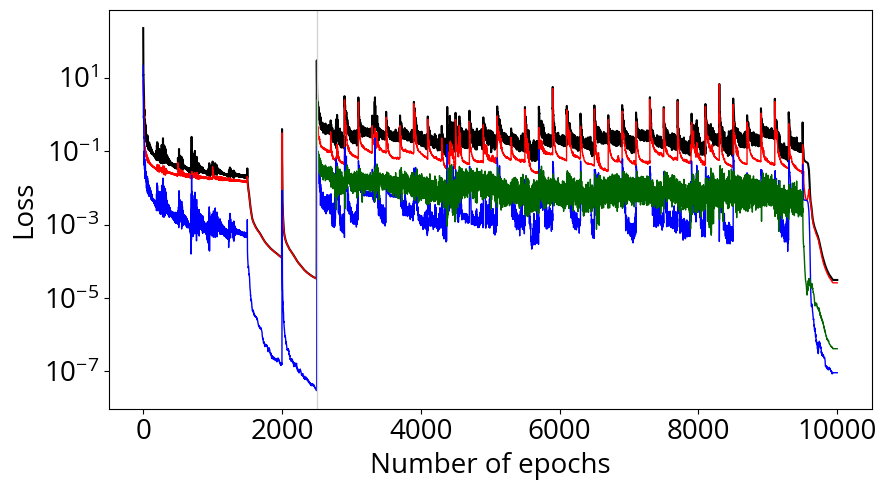

In [41]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

sd = np.array(shock_det_history)   # columns: pde, bc, total  (single net)
dl = np.array(dual_loss_history)   # columns: total, pde_L, pde_R, bc_L, bc_R, interface, x_shock

split_at = len(sd)

total     = np.concatenate([sd[:, 2], dl[:, 0]])
pde       = np.concatenate([sd[:, 0], dl[:, 1] + dl[:, 2]])
bc        = np.concatenate([sd[:, 1], dl[:, 3] + dl[:, 4]])
interface = np.concatenate([np.full(len(sd), np.nan), dl[:, 5]])

epochs = np.arange(len(total))

ax.semilogy(epochs, total, color="black", lw=1.5)
ax.semilogy(epochs, pde, color="red", lw=1)
ax.semilogy(epochs, bc, color="blue", lw=1)
ax.semilogy(epochs, interface, color="darkgreen", lw=1)

ax.axvline(split_at, color="lightgray", lw=1)

ax.set_xlabel("Number of epochs", fontsize=20)
ax.set_ylabel("Loss", fontsize=20)
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)
ax.grid(False)

plt.tight_layout()
plt.savefig("combined_loss_history.svg", format="svg", transparent=True)
plt.show()

In [30]:
# ── New boundary condition for shock at x = 0.9 ───────────────────────────────
X_SHOCK_NEW = 0.9
P_EXIT_NEW = get_back_pressure_from_shock(X_SHOCK_NEW)
print(f"New P_EXIT = {P_EXIT_NEW:.4f}  (was {P_EXIT:.4f})")

# Monkey-patch P_EXIT globally so all loss functions pick it up
P_EXIT = P_EXIT_NEW
X_SHOCK_REF = X_SHOCK_NEW
analytic_new = AnalyticSolution()
analytic_new.x_shock = X_SHOCK_NEW
analytic_new._solve()

# ── Helper: clone weights from an existing trained model ──────────────────────
def clone_weights(src: nn.Module, dst: nn.Module):
    dst.load_state_dict(deepcopy(src.state_dict()))

# ══════════════════════════════════════════════════════════════════════════════
# VARIANT A — full retrain from scratch (new random init)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("VARIANT A: Retraining shock-detection model from scratch")
print("="*60)
shock_det_model_A = UnsteadyNet().to(device)
shock_det_history_A, _ = shock_det_train(shock_det_model_A)
x_shock_A = predict_shock_location(shock_det_model_A)

print("\nTraining dual network from scratch (Variant A)...")
pre_model_A, post_model_A, shock_param_A, dual_history_A, _ = dual_network_training_loop(x_shock_A)

# ══════════════════════════════════════════════════════════════════════════════
# VARIANT B — warm-start: copy old coarse (shock-detection) weights, retrain dual
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("VARIANT B: Warm-start from old shock-detection model weights")
print("="*60)
shock_det_model_B = UnsteadyNet().to(device)
clone_weights(shock_detection_model, shock_det_model_B)   # copy OLD coarse weights
shock_det_history_B, _ = shock_det_train(shock_det_model_B)
x_shock_B = predict_shock_location(shock_det_model_B)

print("\nTraining dual network warm-started from old coarse weights (Variant B)...")
pre_model_B, post_model_B, shock_param_B, dual_history_B, _ = dual_network_training_loop(x_shock_B)

New P_EXIT = 0.7101  (was 0.7101)

VARIANT A: Retraining shock-detection model from scratch
[shock_det_model] Adam phase (1500 epochs)
  epoch  500/1500  pde=1.6737e-02  bc=3.8757e-03  total=5.5494e-02
  epoch 1000/1500  pde=1.5704e-02  bc=2.6749e-03  total=4.2453e-02
  epoch 1500/1500  pde=1.1541e-02  bc=9.2991e-04  total=2.0840e-02
[shock_det_model] L-BFGS phase (1000 epochs)…
  L-BFGS  100/1000  pde=7.4591e-03  bc=3.6643e-05  total=7.8256e-03
  L-BFGS  200/1000  pde=5.7154e-03  bc=2.0238e-05  total=5.9178e-03
  L-BFGS  300/1000  pde=4.7218e-03  bc=1.5158e-05  total=4.8733e-03
  L-BFGS  400/1000  pde=4.0349e-03  bc=1.0947e-05  total=4.1444e-03
  L-BFGS  500/1000  pde=3.5782e-03  bc=9.6497e-06  total=3.6747e-03
  L-BFGS  600/1000  pde=2.4678e-03  bc=9.8784e-06  total=2.5666e-03
  L-BFGS  700/1000  pde=3.7298e-04  bc=7.9091e-07  total=3.8089e-04
  L-BFGS  800/1000  pde=2.6672e-04  bc=3.0775e-07  total=2.6979e-04
  L-BFGS  900/1000  pde=1.8356e-04  bc=2.3235e-07  total=1.8588e-04
  L-BF

In [ ]:
X_SHOCK_NEW = 0.9
P_EXIT_NEW = get_back_pressure_from_shock(X_SHOCK_NEW)
print(f"New P_EXIT = {P_EXIT_NEW:.4f}  (was {P_EXIT:.4f})")

# Monkey-patch P_EXIT globally so all loss functions pick it up
P_EXIT = P_EXIT_NEW
X_SHOCK_REF = X_SHOCK_NEW
analytic_new = AnalyticSolution()
analytic_new.x_shock = X_SHOCK_NEW
analytic_new._solve()

def dual_network_training_loop_C(
    label: str,
    init_net_L: UnsteadyNet | None = None,
    init_net_R: UnsteadyNet | None = None,
    init_shock_x: float = X_SHOCK_NEW,
):
    """
    Variant C  – train from scratch (init_net_L/R = None)
                 or warm-start from supplied network weights.
    Identical to dual_network_training_loop but uses X_SHOCK_NEW as prior
    centre so the shock prior pulls toward 0.9 instead of 0.75.
    """
    net_L = UnsteadyNet().to(device)
    net_R = UnsteadyNet().to(device)

    if init_net_L is not None:
        net_L.load_state_dict(init_net_L.state_dict())
        print(f"[{label}] Loaded weights into net_L from supplied model.")
    else:
        net_L.load_state_dict(shock_detection_model.state_dict())
        print(f"[{label}] Initialised net_L from shock-detection model.")

    if init_net_R is not None:
        net_R.load_state_dict(init_net_R.state_dict())
        print(f"[{label}] Loaded weights into net_R from supplied model.")
    else:
        net_R.load_state_dict(shock_detection_model.state_dict())
        print(f"[{label}] Initialised net_R from shock-detection model.")

    shock = ShockParam(init_shock_x).to(device)
    last_x_shock = init_shock_x

    pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
    pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

    best_L, snap_L = float("inf"), {}
    best_R, snap_R = float("inf"), {}
    best_I, snap_I = float("inf"), {}
    loss_history = []

    # ── Adam phase ────────────────────────────────────────────────────────────
    model_params = list(net_L.parameters()) + list(net_R.parameters())
    model_opt = torch.optim.Adam(model_params, lr=DUAL_NET_ADAM_LR)
    shock_opt = torch.optim.Adam(shock.parameters(), lr=DUAL_NET_SHOCK_LR)
    print(f"[{label}] Adam phase ({DUAL_NET_ADAM_EPOCHS} epochs)…")

    for epoch in range(DUAL_NET_ADAM_EPOCHS):
        if epoch % DUAL_NET_RESAMPLE_EVERY == 0:
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

        if epoch % REMESH_EVERY == 0 and epoch > 0:
            new_xs = shock.clamped_x().item()
            if abs(new_xs - last_x_shock) > REMESH_SHIFT_TOL:
                last_x_shock = new_xs
                pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
                pts_R = sample_points(
                    last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS
                )
                print(
                    f"  [{label}] Remesh at epoch {epoch}: x_shock = {last_x_shock:.6f}"
                )

        t_interface = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
        interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior = (shock.clamped_x() - X_SHOCK_NEW) ** 2  # <-- new prior centre

        pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L).pow(2).mean()
        pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R).pow(2).mean()
        bc_L = DualUnsteadyLoss._left_bc(net_L, pts_L)
        bc_R = DualUnsteadyLoss._right_bc(net_R, pts_R)

        loss = (
            pde_L
            + pde_R
            + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
            + DUAL_NET_INTERFACE_WEIGHT * interface
            + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
        )

        if not torch.isfinite(loss):
            if snap_L:
                net_L.load_state_dict(snap_L)
            if snap_R:
                net_R.load_state_dict(snap_R)
            if snap_I:
                shock.load_state_dict(snap_I)
            print(
                f"  [{label}] NaN at epoch {epoch} — restored best snapshot, continuing"
            )
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
            continue

        model_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model_params, DUAL_NET_GRAD_CLIP)
        for p in shock.parameters():
            p.grad = None
        model_opt.step()

        shock_opt.zero_grad()
        interface2 = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior2 = DUAL_NET_SHOCK_PRIOR_WEIGHT * (shock.clamped_x() - X_SHOCK_NEW) ** 2
        shock_loss = DUAL_NET_INTERFACE_WEIGHT * interface2 + prior2
        shock_loss.backward()
        shock_opt.step()

        loss_history.append(
            (
                loss.item(),
                pde_L.item(),
                pde_R.item(),
                bc_L.item(),
                bc_R.item(),
                interface.item(),
                shock.clamped_x().item(),
            )
        )
        best_L, snap_L = ModelHandler.update_best(net_L, loss.item(), best_L, snap_L)
        best_R, snap_R = ModelHandler.update_best(net_R, loss.item(), best_R, snap_R)
        best_I, snap_I = ModelHandler.update_best(shock, loss.item(), best_I, snap_I)

        if (epoch + 1) % DUAL_NET_PRINT_EVERY == 0:
            xs = shock.clamped_x().item()
            with torch.no_grad():
                xt_s = torch.tensor([[xs, T_STEADY]], device=device)
                o_L, o_R = net_L(xt_s), net_R(xt_s)
                M_L = (o_L[0, 1] / torch.sqrt(GAMMA * o_L[0, 2] / o_L[0, 0])).item()
                M_R = (o_R[0, 1] / torch.sqrt(GAMMA * o_R[0, 2] / o_R[0, 0])).item()
            print(
                f"  [{label}] epoch {epoch+1}/{DUAL_NET_ADAM_EPOCHS}  x_shock={xs:.5f}  "
                f"loss={loss.item():.4e}  "
                f"pde=({pde_L.item():.3e},{pde_R.item():.3e})  "
                f"bc=({bc_L.item():.3e},{bc_R.item():.3e})  "
                f"interface={interface.item():.3e}  "
                f"M@shock: pre={M_L:.3f}(>1) post={M_R:.3f}(<1)"
            )

    net_L.load_state_dict(snap_L)
    net_R.load_state_dict(snap_R)
    shock.load_state_dict(snap_I)

    # ── L-BFGS phase ─────────────────────────────────────────────────────────
    print(f"[{label}] L-BFGS phase ({DUAL_NET_LBFGS_EPOCHS} epochs)…")
    all_lbfgs_params = (
        list(net_L.parameters()) + list(net_R.parameters()) + list(shock.parameters())
    )
    last = {"nan": False}

    def mk_closure(optim, pts_L_lbfgs, pts_R_lbfgs, t_interface_lbfgs):
        def closure_dual():
            optim.zero_grad()
            pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L_lbfgs).pow(2).mean()
            pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R_lbfgs).pow(2).mean()

            bc_L = DualUnsteadyLoss._left_bc(net_L, pts_L_lbfgs)
            bc_R = DualUnsteadyLoss._right_bc(net_R, pts_R_lbfgs)

            interface = DualUnsteadyLoss.interface(
                shock, net_L, net_R, t_interface_lbfgs
            )
            prior = (shock.clamped_x() - X_SHOCK_REF) ** 2

            loss = (
                pde_L
                + pde_R
                + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
                + DUAL_NET_INTERFACE_WEIGHT * interface
                + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
            )

            if not torch.isfinite(loss):
                last["nan"] = True
                return loss

            loss.backward()
            nn.utils.clip_grad_norm_(all_lbfgs_params, DUAL_NET_GRAD_CLIP)  # NEW
            last["nan"] = False
            loss_data = (
                loss.item(),
                pde_L.item(),
                pde_R.item(),
                bc_L.item(),
                bc_R.item(),
                interface.item(),
                shock.clamped_x().item(),
            )

            last["loss"] = loss_data  # type: ignore
            return loss

        return closure_dual

    epoch = 0
    consecutive_nan = 0
    lbfgs = torch.optim.LBFGS(
        all_lbfgs_params,
        line_search_fn="strong_wolfe",
        lr=0.5 if consecutive_nan == 0 else 0.5 * (0.5**consecutive_nan),
    )

    while epoch < DUAL_NET_LBFGS_EPOCHS:
        pts_L_lbfgs = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
        pts_R_lbfgs = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
        t_interface_lbfgs = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
        closure = mk_closure(lbfgs, pts_L_lbfgs, pts_R_lbfgs, t_interface_lbfgs)
        chunk_end = min(epoch + DUAL_NET_LBFGS_RESAMPLE_EVERY, DUAL_NET_LBFGS_EPOCHS)

        for _ in range(epoch, chunk_end):
            lbfgs.step(closure)
            epoch += 1

            if last["nan"]:
                net_L.load_state_dict(snap_L)
                net_R.load_state_dict(snap_R)
                shock.load_state_dict(snap_I)
                consecutive_nan += 1

                lbfgs = torch.optim.LBFGS(
                    all_lbfgs_params,
                    line_search_fn="strong_wolfe",
                    lr=0.5 if consecutive_nan == 0 else 0.5 * (0.5**consecutive_nan),
                )
                print(f"  epoch {epoch}: non-finite loss (attempt {consecutive_nan})")
                break

            consecutive_nan = 0
            loss_history.append(last["loss"])
            best_L, snap_L = ModelHandler.update_best(
                net_L, last["loss"][0], best_L, snap_L  # type: ignore
            )
            best_R, snap_R = ModelHandler.update_best(
                net_R, last["loss"][0], best_R, snap_R  # type: ignore
            )
            best_I, snap_I = ModelHandler.update_best(
                shock, last["loss"][0], best_I, snap_I  # type: ignore
            )

            if (epoch + 1) % max(1, DUAL_NET_PRINT_EVERY // 10) == 0:
                xs = shock.clamped_x().item()
                with torch.no_grad():
                    xt_s = torch.tensor([[xs, T_STEADY]], device=device)
                    o_L, o_R = net_L(xt_s), net_R(xt_s)
                    M_L = (o_L[0, 1] / torch.sqrt(GAMMA * o_L[0, 2] / o_L[0, 0])).item()
                    M_R = (o_R[0, 1] / torch.sqrt(GAMMA * o_R[0, 2] / o_R[0, 0])).item()
                print(
                    f"  epoch {epoch+1}/{DUAL_NET_LBFGS_EPOCHS}  x_shock={xs:.5f}  "
                    f"loss={last['loss'][0]:.4e}  "  # type: ignore
                    f"pde=({last['loss'][1]:.3e},{last['loss'][2]:.3e})  "  # type: ignore
                    f"bc=({last['loss'][3]:.3e},{last['loss'][4]:.3e})  "  # type: ignore
                    f"interface={last['loss'][5]:.3e}  "  # type: ignore
                    f"M@shock: pre={M_L:.3f}(>1) post={M_R:.3f}(<1)"
                )

        if consecutive_nan >= DUAL_MAX_CONSECUTIVE_NAN:
            print(
                f"  L-BFGS phase aborted at epoch {epoch}: {DUAL_MAX_CONSECUTIVE_NAN} consecutive non-finite steps."
            )
            break

    net_L.load_state_dict(snap_L)
    net_R.load_state_dict(snap_R)
    shock.load_state_dict(snap_I)

    suffix = label.lower().replace(" ", "_")
    path_L = ModelHandler.save_path(f"dual_net_pre_{suffix}")
    path_R = ModelHandler.save_path(f"dual_net_post_{suffix}")
    path_I = ModelHandler.save_path(f"interface_{suffix}")
    ModelHandler.save(net_L, path_L)
    ModelHandler.save(net_R, path_R)
    ModelHandler.save(shock, path_I)

    return net_L, net_R, shock, loss_history, (path_L, path_R, path_I)


# ── Variant C: train completely from scratch with new P_EXIT ───────────────────
print("=" * 60)
print("VARIANT C — from scratch, x_shock prior → 0.9")
print("=" * 60)
pre_C, post_C, shock_C, loss_history_C, paths_C = dual_network_training_loop_C(
    label="Variant C",
    init_net_L=shock_detection_model,  # copy weights from original trained coarse network
    init_net_R=shock_detection_model,  # copy weights from original trained coarse network
    init_shock_x=x_shock,
)

# ── Variant D: warm-start from the original trained dual networks ──────────────
print("=" * 60)
print("VARIANT D — warm-start from original trained dual nets, x_shock prior → 0.9")
print("=" * 60)
pre_D, post_D, shock_D, loss_history_D, paths_D = dual_network_training_loop_C(
    label="Variant D",
    init_net_L=pre_shock_model,  # copy weights from original trained net_L
    init_net_R=post_shock_model,  # copy weights from original trained net_R
    init_shock_x=shock_param.clamped_x().item(),  # start shock from where it converged
)

New P_EXIT = 0.7101  (was 0.7101)
VARIANT D — warm-start from original trained dual nets, x_shock prior → 0.9
[Variant D] Loaded weights into net_L from supplied model.
[Variant D] Loaded weights into net_R from supplied model.
[Variant D] Adam phase (6000 epochs)…
  [Variant D] epoch 500/6000  x_shock=0.78357  loss=7.1796e+00  pde=(1.969e-02,8.970e-03)  bc=(7.003e-01,4.166e-04)  interface=7.598e-03  M@shock: pre=2.322(>1) post=0.539(<1)
  [Variant D] Remesh at epoch 600: x_shock = 0.791290
  [Variant D] epoch 1000/6000  x_shock=0.80699  loss=9.0018e+00  pde=(3.253e-02,2.017e-02)  bc=(8.613e-01,7.165e-04)  interface=2.852e-02  M@shock: pre=3.376(>1) post=0.447(<1)
  [Variant D] Remesh at epoch 1200: x_shock = 0.816417
  [Variant D] epoch 1500/6000  x_shock=0.83368  loss=7.4761e+00  pde=(1.702e-02,6.001e-03)  bc=(7.402e-01,6.296e-05)  interface=2.832e-03  M@shock: pre=3.325(>1) post=0.460(<1)
  [Variant D] Remesh at epoch 1800: x_shock = 0.850634
  [Variant D] epoch 2000/6000  x_shock=0

/tmp/ipykernel_685715/205643258.py:51: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Open Sans.
  plt.tight_layout()
/home/prantik/projects/qsnippets/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Open Sans.
  fig.canvas.print_figure(bytes_io, **kw)


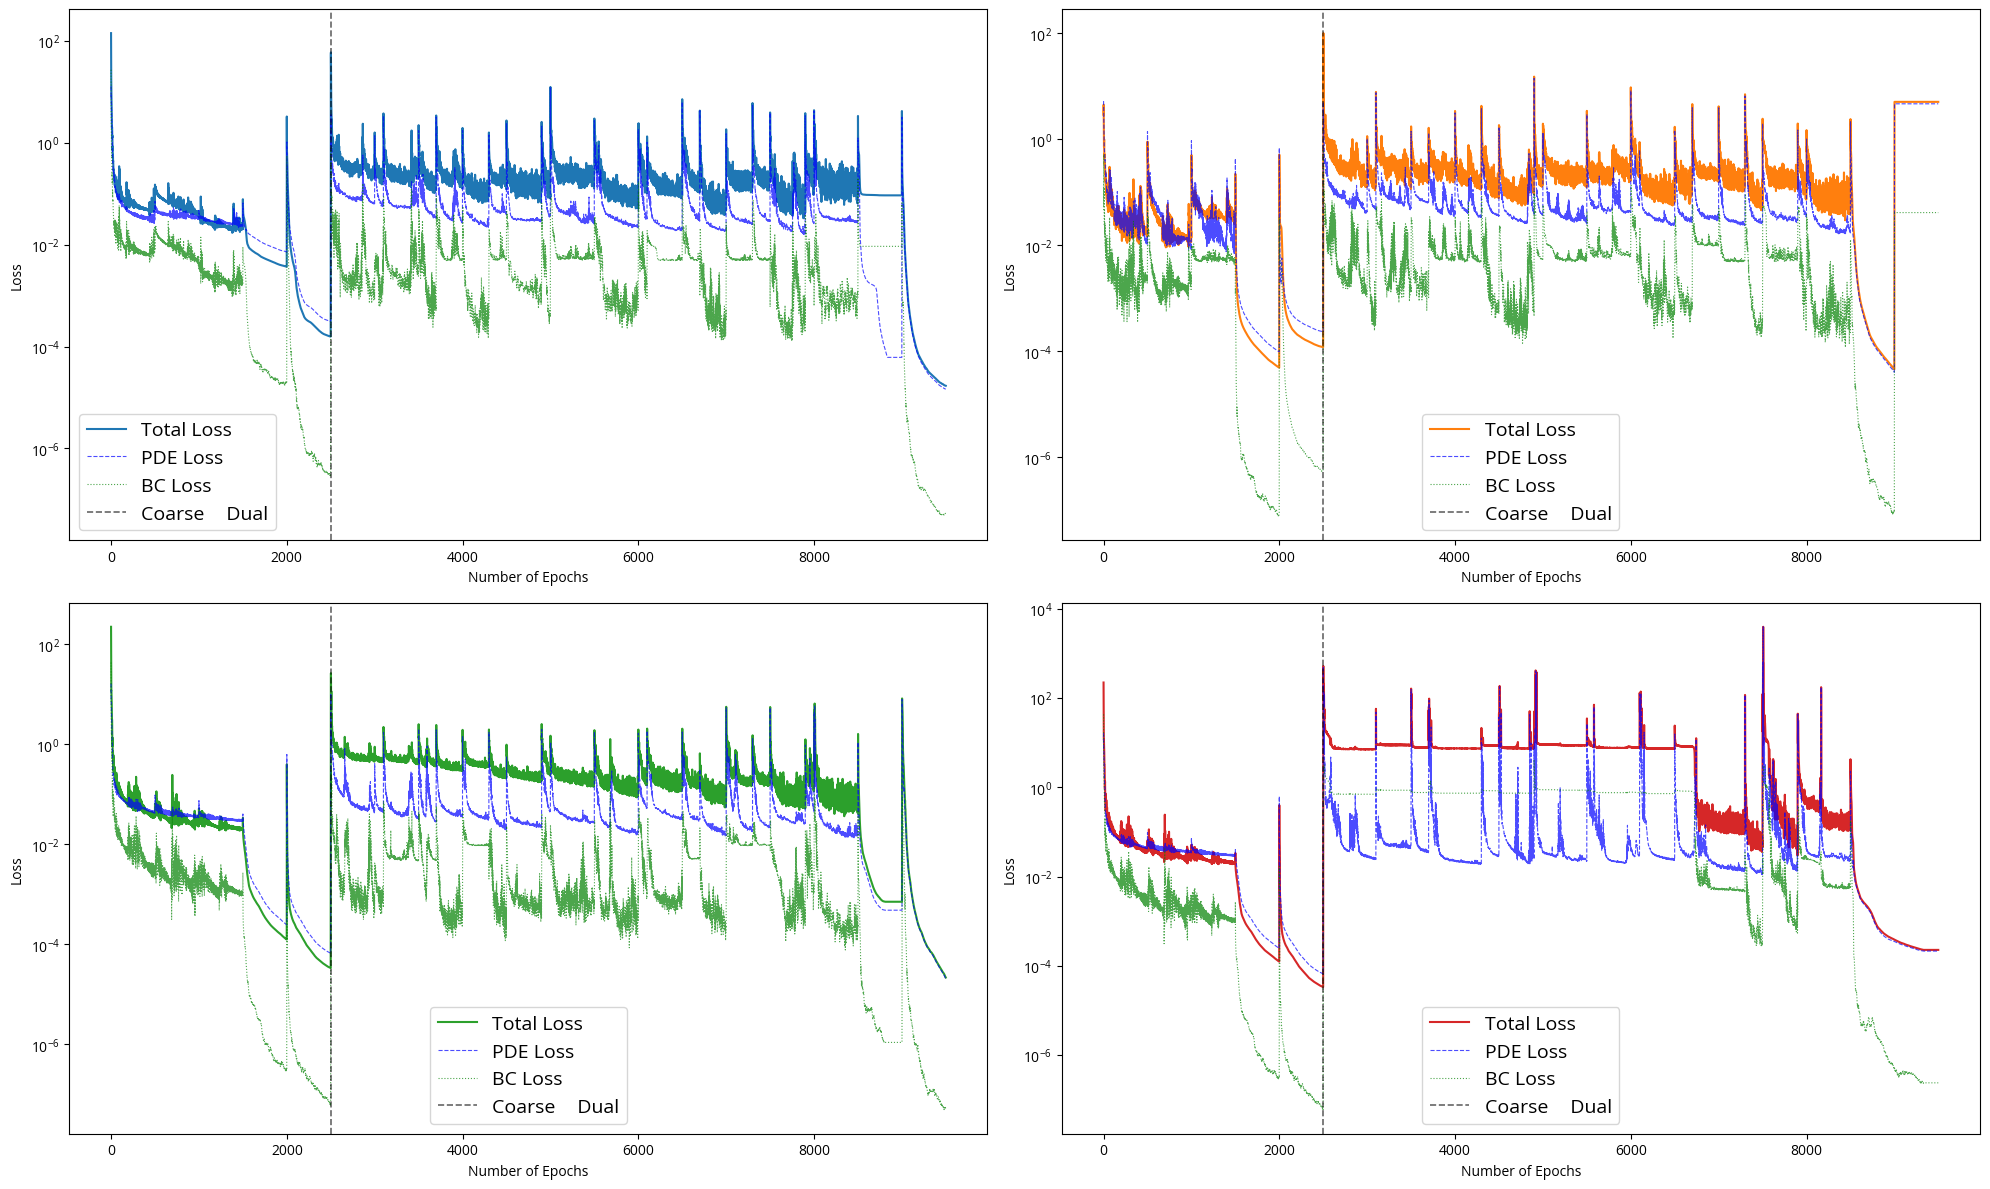

In [62]:
def combine_coarse_and_dual(coarse_hist, dual_hist):
    """
    coarse_hist: list of (pde, bc, total)  → we want total as col 0, pad others with NaN
    dual_hist:   list of (total, pde_L, pde_R, bc_L, bc_R, interface, x_shock)
    Returns a single array with columns matching dual_hist format, and the split index.
    """
    coarse = np.array(coarse_hist)   # shape (N, 3): pde, bc, total
    dual   = np.array(dual_hist)     # shape (M, 7)

    # Build coarse rows in dual format: [total, pde≈col0, pde≈col0, bc≈col1, bc≈col1, NaN, NaN]
    coarse_padded = np.full((len(coarse), dual.shape[1]), np.nan)
    coarse_padded[:, 0] = coarse[:, 2]   # total
    coarse_padded[:, 1] = coarse[:, 0]   # pde → PDE L slot
    coarse_padded[:, 2] = coarse[:, 0]   # pde → PDE R slot (same, single net)
    coarse_padded[:, 3] = coarse[:, 1]   # bc  → BC L slot
    coarse_padded[:, 4] = coarse[:, 1]   # bc  → BC R slot (same, single net)

    combined = np.concatenate([coarse_padded, dual], axis=0)
    return combined, len(coarse)


def plot_configs(configs, ax_slice):
    for ax, (coarse_hist, dual_hist, _, color) in zip(ax_slice, configs):
        dl, split_at = combine_coarse_and_dual(coarse_hist, dual_hist)
        epochs = np.arange(len(dl))
        # plot pde summed and bc summed
        dl[:, 1] += dl[:, 2]   # PDE L + PDE R
        dl[:, 3] += dl[:, 4]   # BC L + BC R
        ax.semilogy(epochs, dl[:, 0], color=color,    lw=1.5,           label="Total Loss")
        ax.semilogy(epochs, dl[:, 1], color="blue",   lw=0.8, ls="--", alpha=0.7, label="PDE Loss")
        ax.semilogy(epochs, dl[:, 3], color="green",  lw=0.8, ls=":",  alpha=0.7, label="BC Loss")
        ax.axvline(split_at, color="black", lw=1.2, ls="--", alpha=0.6, label="Coarse → Dual")
        ax.set_xlabel("Number of Epochs"); ax.set_ylabel("Loss") #; ax.set_title(label)
        ax.grid(False)
        ax.legend(fontsize=14)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

configs_1 = [
    (shock_det_history_A, dual_history_A, "Variant A — from scratch",                "tab:blue"),
    (shock_det_history_B, dual_history_B, "Variant B — warm-start coarse to coarse", "tab:orange"),
]
configs_2 = [
    (shock_det_history, loss_history_C, "Variant C — warm-start coarse to dual",   "tab:green"),
    (shock_det_history, loss_history_D, "Variant D — warm-start dual to dual",     "tab:red"),
]

plot_configs(configs_1, axes[0])
plot_configs(configs_2, axes[1])

plt.tight_layout()
plt.show()

In [42]:
def save_variant(
    variant: str,
    kind: str,                 # "single" or "dual"
    loss_history: list,
    models: dict,               # single -> {"model": UnsteadyNet}
                                 # dual   -> {"net_L": ..., "net_R": ..., "shock_param": ...}
    x_shock: float | None = None,
    base_dir: str = "saved_models",
) -> dict:
    """
    Save a variant's training artifacts: loss history (csv), model weights (.pt),
    and shock location (.txt), all under saved_models/<variant>/.

    kind="single": expects models={"model": net}, loss_history rows of
                   (pde_loss, bc_loss, total_loss).
    kind="dual":   expects models={"net_L": ..., "net_R": ..., "shock_param": ...},
                   loss_history rows of
                   (total_loss, pde_L, pde_R, bc_L, bc_R, interface_loss, shock_location).
    """
    if kind not in ("single", "dual"):
        raise ValueError(f"kind must be 'single' or 'dual', got {kind!r}")

    variant_dir = os.path.join(base_dir, variant)
    os.makedirs(variant_dir, exist_ok=True)
    ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

    # ── 1. loss history ────────────────────────────────────────────────
    columns = (
        ["pde_loss", "bc_loss", "total_loss"]
        if kind == "single"
        else ["total_loss", "pde_L", "pde_R", "bc_L", "bc_R", "interface_loss", "shock_location"]
    )
    df = pd.DataFrame(loss_history, columns=columns)
    hist_path = os.path.join(variant_dir, f"{variant}_history.csv")
    df.to_csv(hist_path, index=False)
    print(f"  [{variant}] Saved loss history -> {hist_path}")

    # ── 2. model weights (one file per entry in `models`) ─────────────
    saved_model_paths = {}
    for name, model in models.items():
        path = os.path.join(variant_dir, f"{variant}_{name}.{ts}.pt")
        torch.save(model.state_dict(), path)
        saved_model_paths[name] = path
        print(f"  [{variant}] Saved {name} -> {path}")

    # ── 3. shock location ───────────────────────────────────────────────
    if x_shock is None:
        if kind == "dual" and "shock_param" in models:
            x_shock = models["shock_param"].clamped_x().item()
        elif kind == "single" and "model" in models:
            x_shock = predict_shock_location(models["model"])

    shock_path = None
    if x_shock is not None:
        shock_path = os.path.join(variant_dir, f"{variant}_shock_location.txt")
        with open(shock_path, "w") as f:
            f.write(f"{x_shock:.6f}\n")
        print(f"  [{variant}] Saved shock location ({x_shock:.6f}) -> {shock_path}")

    return {
        "dir": variant_dir,
        "history_csv": hist_path,
        "models": saved_model_paths,
        "shock_location_txt": shock_path,
        "x_shock": x_shock,
    }

In [63]:
# Single-net shock-detection variants
save_variant("SHOCK_SINGLE_075", "single",
             shock_det_history, {"model": shock_detection_model}) # type: ignore

save_variant("VARIANT_A_coarse", "single",
             shock_det_history_A, {"model": shock_det_model_A})

save_variant("VARIANT_B_coarse", "single",
             shock_det_history_B, {"model": shock_det_model_B})

# Dual-net variants
save_variant("VARIANT_A_dual", "dual", dual_history_A,
             {"net_L": pre_model_A, "net_R": post_model_A, "shock_param": shock_param_A})

save_variant("VARIANT_B_dual", "dual", dual_history_B,
             {"net_L": pre_model_B, "net_R": post_model_B, "shock_param": shock_param_B})

save_variant("VARIANT_C_dual", "dual", loss_history_C,
             {"net_L": pre_C, "net_R": post_C, "shock_param": ShockParam(0.0)})

save_variant("VARIANT_D_dual", "dual", loss_history_D,
             {"net_L": pre_D, "net_R": post_D, "shock_param": ShockParam(0.0)})

  [VARIANT_D_dual] Saved loss history -> saved_models/VARIANT_D_dual/VARIANT_D_dual_history.csv
  [VARIANT_D_dual] Saved net_L -> saved_models/VARIANT_D_dual/VARIANT_D_dual_net_L.2026-08-05_01-12-48.pt
  [VARIANT_D_dual] Saved net_R -> saved_models/VARIANT_D_dual/VARIANT_D_dual_net_R.2026-08-05_01-12-48.pt
  [VARIANT_D_dual] Saved shock_param -> saved_models/VARIANT_D_dual/VARIANT_D_dual_shock_param.2026-08-05_01-12-48.pt
  [VARIANT_D_dual] Saved shock location (0.500010) -> saved_models/VARIANT_D_dual/VARIANT_D_dual_shock_location.txt


{'dir': 'saved_models/VARIANT_D_dual',
 'history_csv': 'saved_models/VARIANT_D_dual/VARIANT_D_dual_history.csv',
 'models': {'net_L': 'saved_models/VARIANT_D_dual/VARIANT_D_dual_net_L.2026-08-05_01-12-48.pt',
  'net_R': 'saved_models/VARIANT_D_dual/VARIANT_D_dual_net_R.2026-08-05_01-12-48.pt',
  'shock_param': 'saved_models/VARIANT_D_dual/VARIANT_D_dual_shock_param.2026-08-05_01-12-48.pt'},
 'shock_location_txt': 'saved_models/VARIANT_D_dual/VARIANT_D_dual_shock_location.txt',
 'x_shock': 0.5000100135803223}

In [28]:
# ── Reload saved variants A-D (+ shock) from disk, skip retraining ──────────
# Reconstructs everything build_variant_plots()/VARIANT_CONFIG need:
#   pre_model_A/B, post_model_A/B, shock_param_A/B, dual_history_A/B
#   pre_C, post_C, shock_C, loss_history_C
#   pre_D, post_D, shock_D, loss_history_D
#   analytic_new (analytical solution at the shifted shock, x = 0.9)
# Assumes UnsteadyNet, ShockParam, AnalyticSolution, get_back_pressure_from_shock,
# and `device` are already defined (earlier cells in this notebook).

import glob

SAVED_MODELS_DIR = "saved_models"


def _latest_file(pattern: str) -> str:
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No files matching: {pattern}")
    return files[-1]  # timestamp suffix sorts chronologically as a string


def load_single_variant(variant: str, base_dir: str = SAVED_MODELS_DIR):
    """Reload a single-net (shock-detection) variant: model, loss history, x_shock."""
    variant_dir = os.path.join(base_dir, variant)

    model = UnsteadyNet().to(device)
    model_path = _latest_file(os.path.join(variant_dir, f"{variant}_model.*.pt"))
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    history = np.loadtxt(
        os.path.join(variant_dir, f"{variant}_history.csv"), delimiter=",", skiprows=1
    )

    x_shock = None
    shock_txt = os.path.join(variant_dir, f"{variant}_shock_location.txt")
    if os.path.exists(shock_txt):
        with open(shock_txt) as f:
            x_shock = float(f.read().strip())

    print(f"  Loaded single-net variant '{variant}' <- {model_path}")
    return model, history, x_shock


def load_dual_variant(variant: str, base_dir: str = SAVED_MODELS_DIR):
    """Reload a dual-net variant: net_L, net_R, shock_param, loss history."""
    variant_dir = os.path.join(base_dir, variant)

    net_L = UnsteadyNet().to(device)
    net_R = UnsteadyNet().to(device)
    shock_param = ShockParam(0.0).to(device)

    net_L_path = _latest_file(os.path.join(variant_dir, f"{variant}_net_L.*.pt"))
    net_R_path = _latest_file(os.path.join(variant_dir, f"{variant}_net_R.*.pt"))
    shock_path = _latest_file(os.path.join(variant_dir, f"{variant}_shock_param.*.pt"))

    net_L.load_state_dict(torch.load(net_L_path, map_location=device))
    net_R.load_state_dict(torch.load(net_R_path, map_location=device))
    shock_param.load_state_dict(torch.load(shock_path, map_location=device))

    net_L.eval()
    net_R.eval()
    shock_param.eval()

    history = np.loadtxt(
        os.path.join(variant_dir, f"{variant}_history.csv"), delimiter=",", skiprows=1
    )

    # Safety net: some saved shock_param checkpoints were written from a fresh
    # ShockParam(0.0) rather than the trained one. Cross-check against the last
    # "shock_location" column of the training history (always the true value)
    # and use that instead if the two disagree.
    hist_shock = float(history[-1, -1]) if history.ndim == 2 else float(history[-1])
    param_shock = shock_param.clamped_x().item()
    if abs(hist_shock - param_shock) > 1e-4:
        print(
            f"  [warn] '{variant}': saved shock_param ({param_shock:.4f}) differs from "
            f"final training shock_location ({hist_shock:.4f}); using the history value."
        )
        with torch.no_grad():
            shock_param.x_shock.copy_(torch.tensor([hist_shock], device=device))

    print(f"  Loaded dual-net variant '{variant}' <- {variant_dir}")
    return net_L, net_R, shock_param, history


# ── Variant A ────────────────────────────────────────────────────────────
shock_det_model_A, shock_det_history_A, x_shock_A = load_single_variant("VARIANT_A_coarse")
pre_model_A, post_model_A, shock_param_A, dual_history_A = load_dual_variant("VARIANT_A_dual")

# ── Variant B ────────────────────────────────────────────────────────────
shock_det_model_B, shock_det_history_B, x_shock_B = load_single_variant("VARIANT_B_coarse")
pre_model_B, post_model_B, shock_param_B, dual_history_B = load_dual_variant("VARIANT_B_dual")

# ── Variant C ────────────────────────────────────────────────────────────
pre_C, post_C, shock_C, loss_history_C = load_dual_variant("VARIANT_C_dual")

# ── Variant D ────────────────────────────────────────────────────────────
pre_D, post_D, shock_D, loss_history_D = load_dual_variant("VARIANT_D_dual")

# ── Original single-shock ("shock") model, x_shock = 0.75 ───────────────
shock_detection_model, shock_det_history, x_shock = load_single_variant("SHOCK_SINGLE_075")

# ── Rebuild the analytic reference at the shifted shock (x = 0.9), as used
#    by VARIANT_CONFIG for A-D ───────────────────────────────────────────
X_SHOCK_NEW = 0.9
P_EXIT_NEW = get_back_pressure_from_shock(X_SHOCK_NEW)
P_EXIT = P_EXIT_NEW
X_SHOCK_REF = X_SHOCK_NEW
analytic_new = AnalyticSolution()
analytic_new.x_shock = X_SHOCK_NEW
analytic_new._solve()

print("\nAll variants (A-D) + shock model reloaded successfully.")

  Loaded single-net variant 'VARIANT_A_coarse' <- saved_models/VARIANT_A_coarse/VARIANT_A_coarse_model.2026-08-04_23-20-40.pt
  Loaded dual-net variant 'VARIANT_A_dual' <- saved_models/VARIANT_A_dual
  Loaded single-net variant 'VARIANT_B_coarse' <- saved_models/VARIANT_B_coarse/VARIANT_B_coarse_model.2026-08-04_23-20-40.pt
  Loaded dual-net variant 'VARIANT_B_dual' <- saved_models/VARIANT_B_dual
  [warn] 'VARIANT_C_dual': saved shock_param (0.5000) differs from final training shock_location (0.9000); using the history value.
  Loaded dual-net variant 'VARIANT_C_dual' <- saved_models/VARIANT_C_dual
  [warn] 'VARIANT_D_dual': saved shock_param (0.5000) differs from final training shock_location (0.9001); using the history value.
  Loaded dual-net variant 'VARIANT_D_dual' <- saved_models/VARIANT_D_dual
  Loaded single-net variant 'SHOCK_SINGLE_075' <- saved_models/SHOCK_SINGLE_075/SHOCK_SINGLE_075_model.2026-08-04_23-20-40.pt

All variants (A-D) + shock model reloaded successfully.


In [29]:
DATA_C = "tab:blue"      # default curve color (override via `color=` if needed)
REF_KW = dict(color="black", linestyle="--", lw=2, label="Analytical")

X_THROAT_OVER_L = X_THROAT / X_LENGTH  # 0.5 — used to mark the throat on x/L axes


def _mark_throat(ax, orientation="vertical"):
    """Draw a line at the throat location on whichever axis carries x/L."""
    # if orientation == "vertical":
    #     ax.axvline(X_THROAT_OVER_L, color="gray", lw=1.8, ls="--", alpha=0.8, label="Throat")
    # else:
    #     ax.axhline(X_THROAT_OVER_L, color="gray", lw=1.8, ls="--", alpha=0.8, label="Throat")


# --------------------------------------------------------------------------
# 1. M, p vs x/L
# --------------------------------------------------------------------------
def plot_M_p_profiles(x_over_L, data, variant, analytical=None, _color=DATA_C,
                       x_shock_pred=None, x_shock_analytical=None, save_path=None):
    """
    data       : dict with keys 'M' and 'p' (arrays aligned with x_over_L)
    analytical : optional dict with the same keys, for the exact/quasi-1D solution
    x_shock_pred, x_shock_analytical : optional x/L locations, drawn as vertical
                 reference lines (predicted vs. analytical shock position)
    """
    fig, axs = plt.subplots(1, 1, figsize=(7.5, 5), constrained_layout=True)


    if x_shock_analytical is not None:
        axs.axvline(x_shock_analytical, color="gray", lw=2, label="Analytical shock")
    if x_shock_pred is not None:
        axs.axvline(x_shock_pred, color="black", lw=2, ls="--", dashes=(5, 5), label="Predicted shock")

    axs.set_xlabel(r"$\text{x}^\prime$", fontsize=20)
    axs.set_ylabel(r"$\text{M}^\prime$", fontsize=20)
    axs.plot(x_over_L, data["M"], color="red", lw=2, label=f"Variant {variant} (M)")

    axs2 = axs.twinx()
    axs2.set_ylabel(r"$\text{p}^\prime$", fontsize=20)
    axs2.plot(x_over_L, data["p"], color="green", lw=2, label=f"Variant {variant} (p)")

    if analytical is not None:
        axs.plot(x_over_L, analytical["M"], dashes=(5, 5), **REF_KW) # type: ignore
        axs2.plot(x_over_L, analytical["p"], dashes=(5, 5), **REF_KW) # type: ignore

    _mark_throat(axs)

    axs.grid(False)
    axs2.grid(False)

    axs.tick_params(axis="x", labelsize=20)
    axs.tick_params(axis="y", labelsize=20)
    axs2.tick_params(axis="y", labelsize=20)

    # lines1, labels1 = axs.get_legend_handles_labels()
    # lines2, labels2 = axs2.get_legend_handles_labels()
    # axs.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=11)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, format="svg")
    return fig


# --------------------------------------------------------------------------
# 2. L2 error of M, p vs x/L
# --------------------------------------------------------------------------
def plot_l2_error_profiles(x_over_L, err, variant, color=DATA_C, save_path=None):
    """
    err : dict with keys 'M' and 'p', each a pointwise L2 error array
          (|pred - analytical|) aligned with x_over_L

    Drawn the same way as `plot_M_p_profiles`: M on the left axis, p on a
    twin right axis, throat marked, grid off, matching fontsize/tick sizes.
    """
    fig, axs = plt.subplots(1, 1, figsize=(7.5, 5), constrained_layout=True)

    axs.set_xlabel(r"$\text{x}^\prime$", fontsize=20)
    axs.set_ylabel(r"$|\hat{\text{M}}-\text{M}|$", fontsize=20)
    axs.set_yscale("log")
    axs.plot(x_over_L, err["M"], color="red", lw=2, label=f"Variant {variant} (M)")

    axs2 = axs.twinx()
    axs2.set_ylabel(r"$|\hat{\text{p}}-\text{p}|$", fontsize=20)
    axs2.set_yscale("log")
    axs2.plot(x_over_L, err["p"], color="green", lw=2, label=f"Variant {variant} (p)")

    _mark_throat(axs)

    axs.grid(False)
    axs2.grid(False)

    axs.tick_params(axis="x", labelsize=20)
    axs.tick_params(axis="y", labelsize=20)
    axs2.tick_params(axis="y", labelsize=20)

    # lines1, labels1 = axs.get_legend_handles_labels()
    # lines2, labels2 = axs2.get_legend_handles_labels()
    # axs.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=11)

    # fig.suptitle(f"Variant {variant}: pointwise L2 error vs x/L")

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, format="svg")
    return fig


# --------------------------------------------------------------------------
# 3. Loss vs epochs
# --------------------------------------------------------------------------
def plot_loss_curve(epochs, loss, variant, adam_iters=None, color=DATA_C, save_path=None):
    """
    epochs     : 1D array of epoch/iteration indices
    loss       : 1D array of total loss values (same length)
    adam_iters : optional epoch index marking the Adam -> L-BFGS handover
    """
    fig, ax = plt.subplots(figsize=(7.5, 5))

    ax.plot(epochs, loss, color="green", lw=2, label=f"Variant {variant}")
    if adam_iters is not None:
        ax.axvline(adam_iters, color="gray", lw=2, linestyle="-.",
                    label="Adam \u2192 L-BFGS")

    ax.set_yscale("log")
    ax.set_xlabel("Number of epochs", fontsize=20)
    ax.set_ylabel("Loss", fontsize=20)

    ax.grid(False)
    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=20)

    # ax.legend(loc="best", fontsize=11)
    # ax.set_title(f"Variant {variant}: loss history")

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, format="svg")
    return fig


# --------------------------------------------------------------------------
# 4. CDF of L2 error of M, p
# --------------------------------------------------------------------------
def plot_l2_error_cdf(x_over_L, err, variant, color=DATA_C, save_path=None):
    """
    err : dict with keys 'M' and 'p', each the *array* of pointwise L2 errors

    Axes were previously swapped/mislabeled (L2 error on x, CDF on y, and
    both M/p curves sharing one legend label). Now: Empirical CDF on x,
    L2 error (log-scaled) on y, and M/p curves clearly labeled separately.
    """
    fig, axs = plt.subplots(1, 1, figsize=(7.5, 5))

    axs.set_xlabel(r"$\text{x}^\prime$", fontsize=20)
    axs.set_ylabel(r"Cumulative sum of $|\hat{\text{M}}-\text{M}|$", fontsize=20)
    # axs.set_yscale("log")
    axs.plot(x_over_L, np.cumsum(err["M"]), color="red", lw=2, label=f"Variant {variant} (M)")

    axs2 = axs.twinx()
    axs2.set_ylabel(r"Cumulative sum of $|\hat{\text{p}}-\text{p}|$", fontsize=20)
    # axs2.set_yscale("log")
    axs2.plot(x_over_L, np.cumsum(err["p"]), color="green", lw=2, label=f"Variant {variant} (p)")

    # axs.plot(p_M, v_M, color="red", lw=2, label=f"Variant {variant} (M)")
    # axs.plot(p_p, v_p, color="blue", lw=2, label=f"Variant {variant} (p)")
    # axs.set_yscale("log")
    # axs.set_xlabel("", fontsize=20)
    # axs.set_ylabel("L2 error", fontsize=20)

    axs.grid(False)
    axs2.grid(False)

    axs.tick_params(axis="x", labelsize=20)
    axs.tick_params(axis="y", labelsize=20)
    axs2.tick_params(axis="y", labelsize=20)

    # axs.legend(loc="best", fontsize=11)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, format="svg")
    return fig


# --------------------------------------------------------------------------
# 5. Loss composition at selected epochs (stacked bar chart)
# --------------------------------------------------------------------------
def plot_loss_composition(components, variant, epochs_to_show=(1000, 3000, 5000, 7000, 9000),
                           terms=("pde", "inlet", "wall", "outlet", "flow_guidance"),
                           total_epochs=None, save_path=None):
    """
    components   : dict {epoch: {term: v, ...}}
                   `v` is the scalar loss contribution at that epoch.
    terms        : ordered iterable of the component keys to stack. Defaults to
                   the single-net breakdown (pde/inlet/wall/outlet/flow_guidance).
                   For the dual-net variants use e.g.
                   terms=("pde", "bc", "interface", "shock_prior").
    total_epochs : if given, x-tick labels show "% of training" instead of the
                   raw epoch numbers, which otherwise look like arbitrary
                   values (e.g. 1583, 3166, ...) depending on how many total
                   epochs a given variant trained for.
    """
    terms = list(terms)
    term_colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(terms))) # type: ignore

    fig, ax = plt.subplots(figsize=(7.5, 5), constrained_layout=True)

    x = np.arange(len(epochs_to_show))
    bottom = np.zeros(len(epochs_to_show))
    for term, c in zip(terms, term_colors):
        vals = np.array([components[ep][term] for ep in epochs_to_show])
        ax.bar(x, vals, bottom=bottom, color=c, label=term,
               edgecolor="white", linewidth=0.5, width=0.6)
        bottom += vals

    ax.set_xticks(x)
    if total_epochs:
        ax.set_xticklabels([f"{100 * e / (total_epochs - 1):.0f}" for e in epochs_to_show])
        ax.set_xlabel("% of Total Epochs", fontsize=20)
    else:
        ax.set_xticklabels([f"epoch {e}" for e in epochs_to_show])
        ax.set_xlabel("% of Total epochs", fontsize=20)
    ax.set_ylabel("% of Loss contribution", fontsize=20)

    ax.grid(False)
    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=20)

    ax.legend(loc="upper right", fontsize=9, ncol=len(terms))
    # ax.set_title(f"Variant {variant}: loss composition")

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, format="svg")
    return fig


# --------------------------------------------------------------------------
# 6. Approach of shock location towards the analytical solution vs epochs
# --------------------------------------------------------------------------
def plot_shock_convergence(epochs, shock_loc, analytical_shock_loc, variant,
                            color=DATA_C, save_path=None):
    """
    epochs                : 1D array of epoch indices at which the predicted
                             shock location (x/L) was measured
    shock_loc              : 1D array of predicted shock location, same length
    analytical_shock_loc   : scalar, the reference/analytical shock location
    """
    fig, axs = plt.subplots(1, 1, figsize=(7.5, 5))
    ax = axs

    ax.plot(epochs, shock_loc, color="green", lw=2, label=f"Variant {variant}")
    ax.axhline(analytical_shock_loc, color="black", lw=2, ls="--", dashes=(5, 5), label="Analytical shock")

    ax.set_xlabel("Number of epochs", fontsize=20)
    ax.set_ylabel(r"$\hat{\text{x}}_\text{s}$", fontsize=20)

    ax.grid(False)
    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=20)

    # ax.legend(loc="best", fontsize=11)
    # fig.suptitle(f"Variant {variant}: shock-location convergence")

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, format="svg")
    return fig

VARIANT A

Variant A shock location: 0.899988  (target: 0.9000)


/tmp/ipykernel_11924/2487256954.py:59: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/tmp/ipykernel_11924/2487256954.py:103: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


Variant A final shock location: 0.899988  (target: 0.9000)
L2 error (M): mean=1.0992e-03  max=2.5244e-03
L2 error (p): mean=6.8706e-04  max=1.1106e-03


/tmp/ipykernel_11924/2487256954.py:233: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


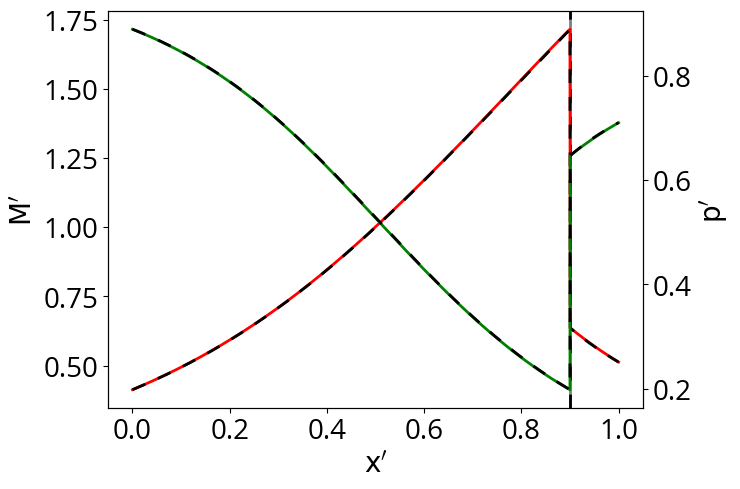

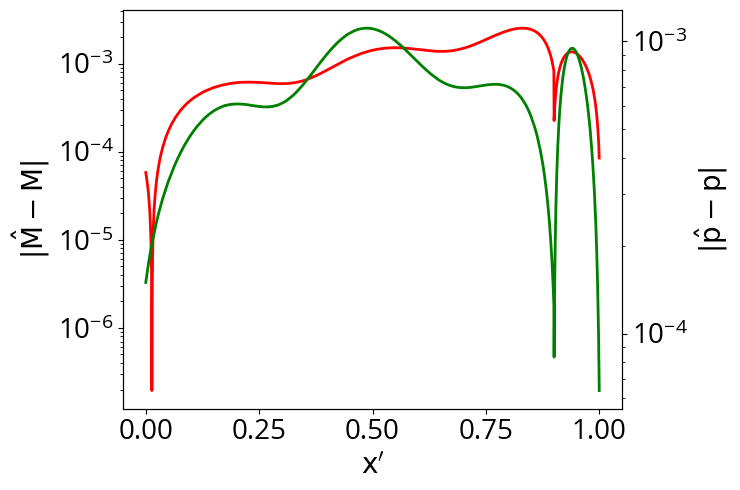

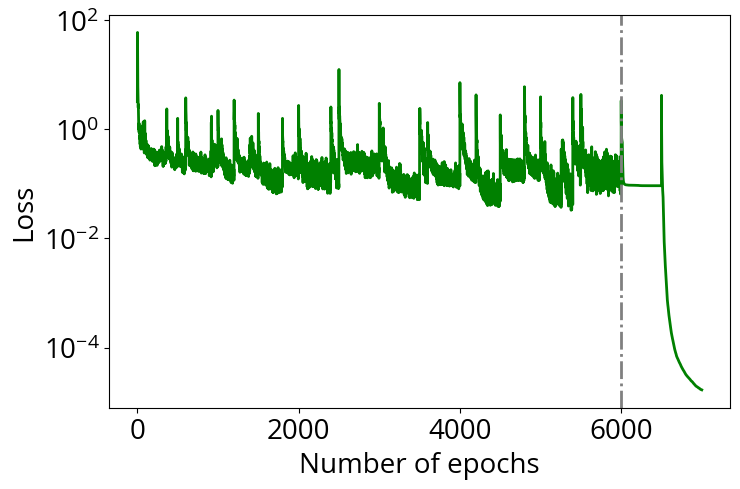

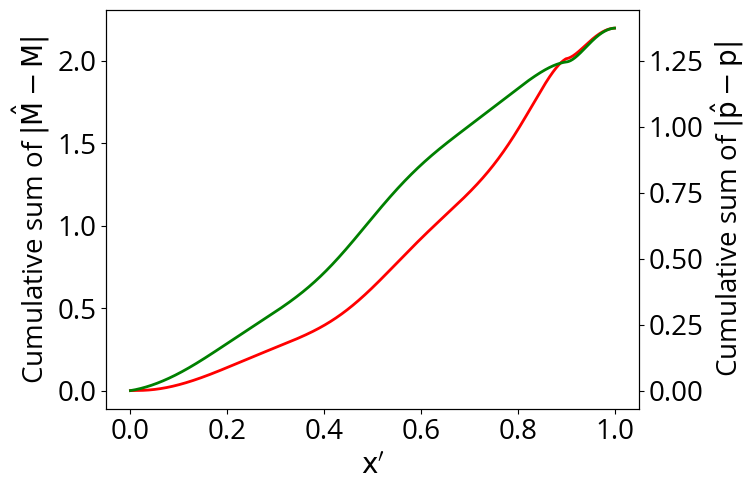

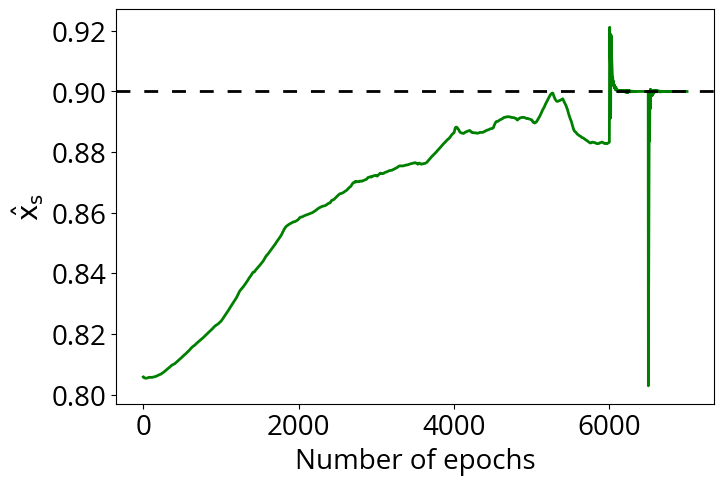

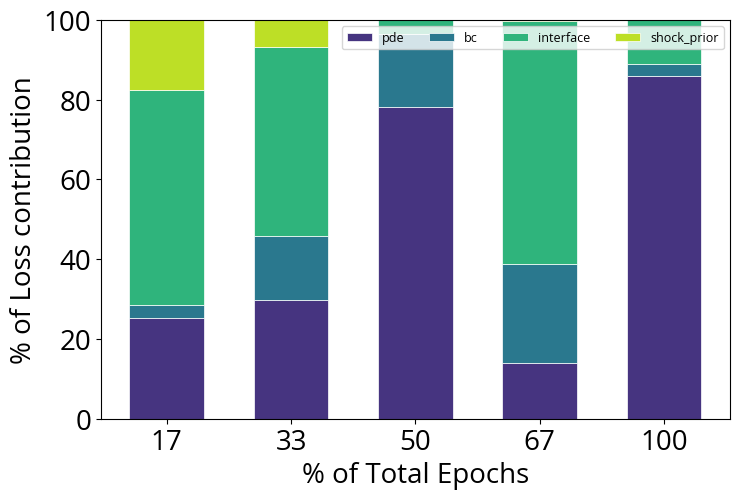

VARIANT B

Variant B shock location: 0.899974  (target: 0.9000)


/tmp/ipykernel_11924/2487256954.py:59: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/tmp/ipykernel_11924/2487256954.py:103: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


Variant B final shock location: 0.899974  (target: 0.9000)
L2 error (M): mean=3.1643e-03  max=9.6698e-03
L2 error (p): mean=1.3124e-03  max=2.7994e-03


/tmp/ipykernel_11924/2487256954.py:233: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


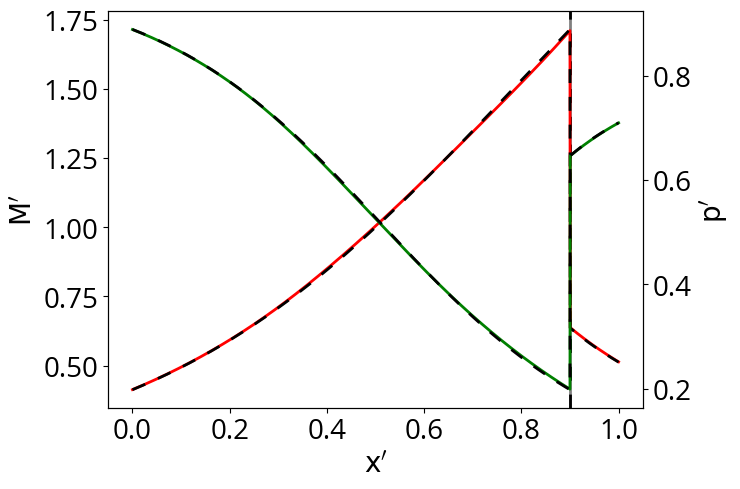

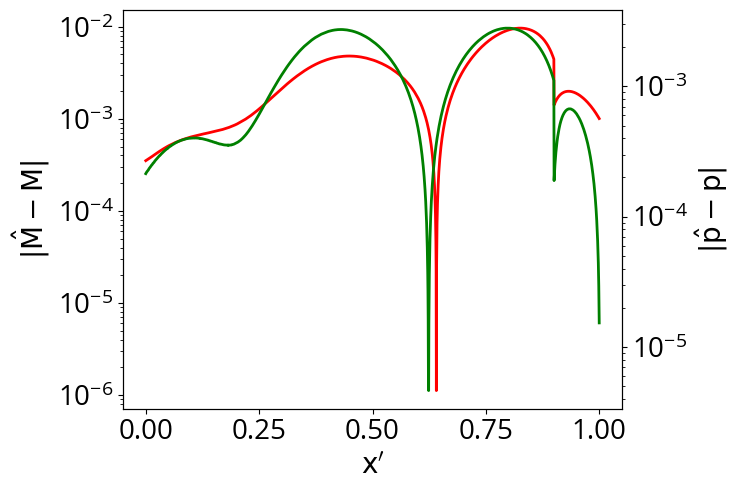

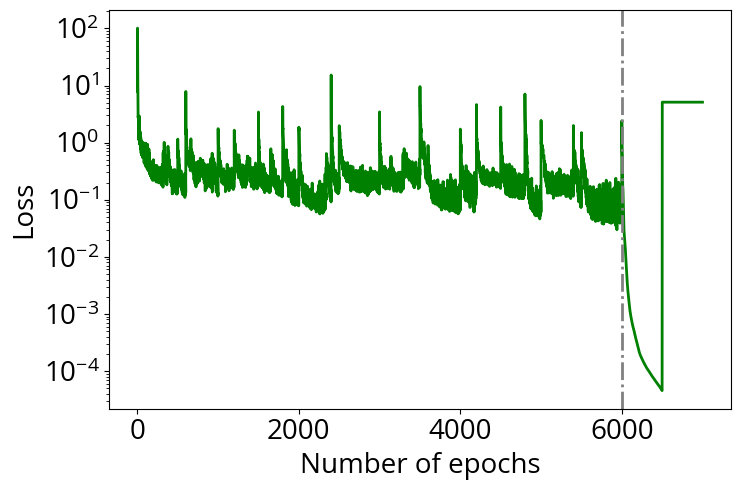

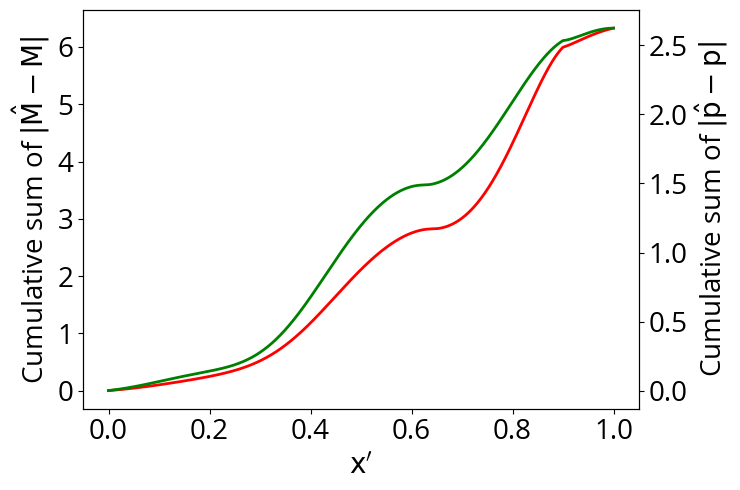

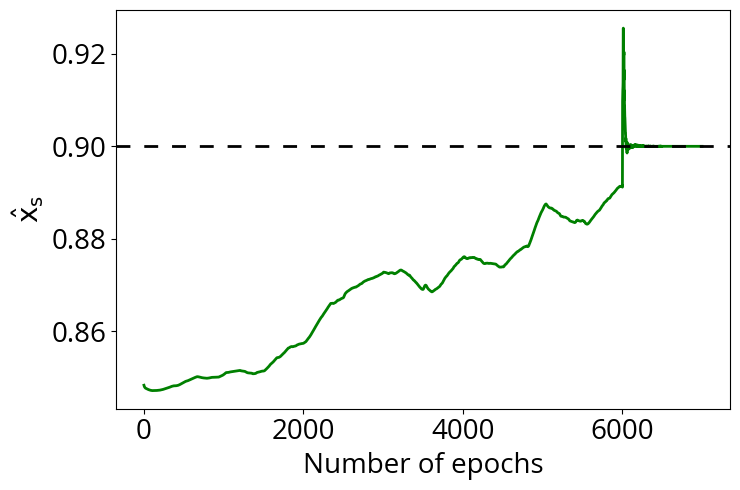

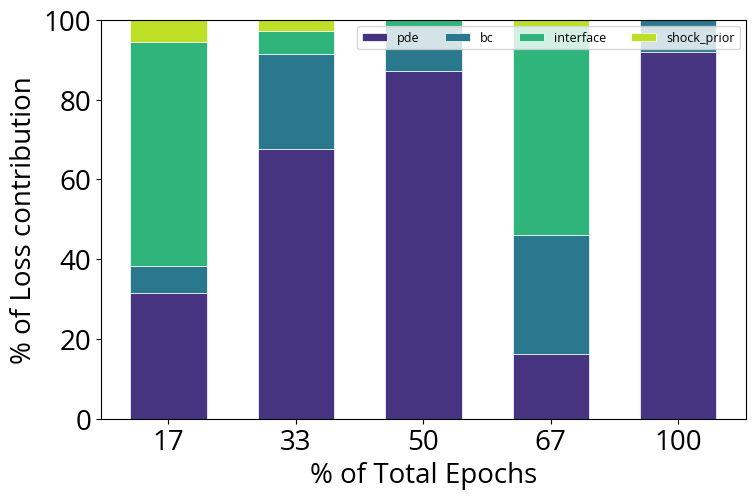

VARIANT C

Variant C shock location: 0.899996  (target: 0.9000)


/tmp/ipykernel_11924/2487256954.py:59: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/tmp/ipykernel_11924/2487256954.py:103: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


Variant C final shock location: 0.899996  (target: 0.9000)
L2 error (M): mean=3.3713e-03  max=1.2069e-02
L2 error (p): mean=1.3334e-03  max=3.2620e-03


/tmp/ipykernel_11924/2487256954.py:233: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


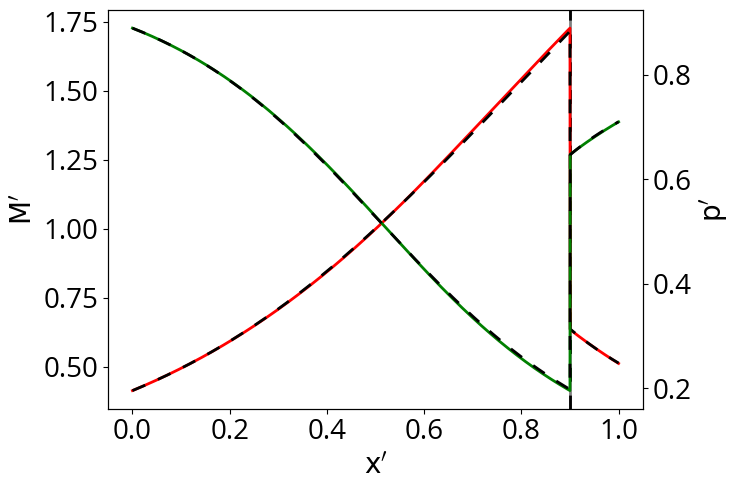

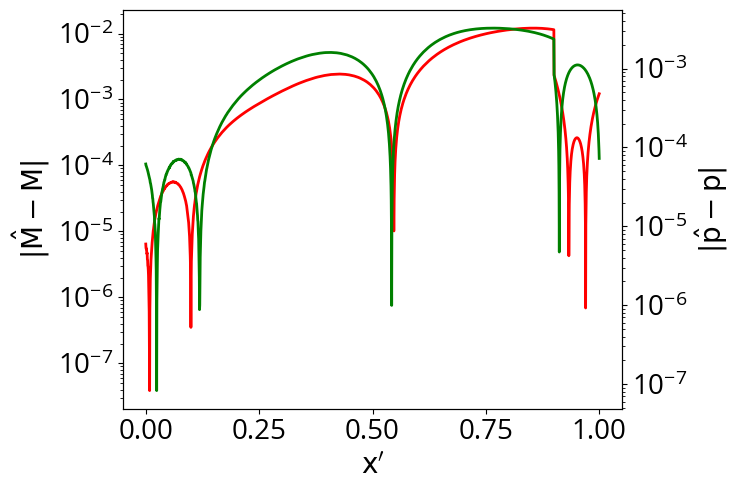

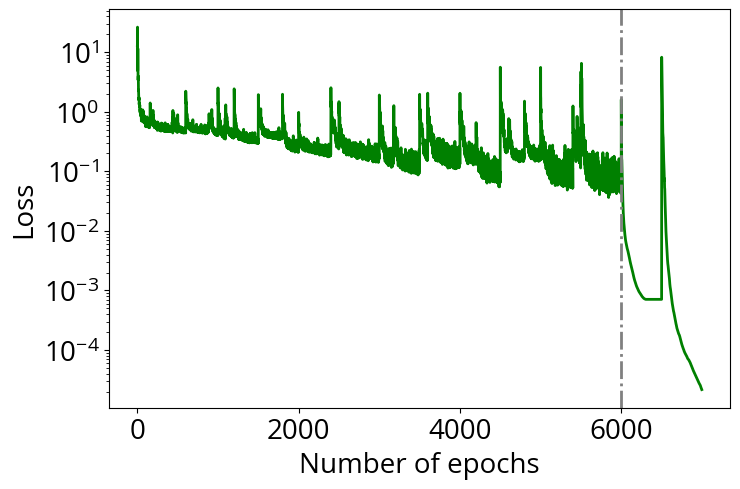

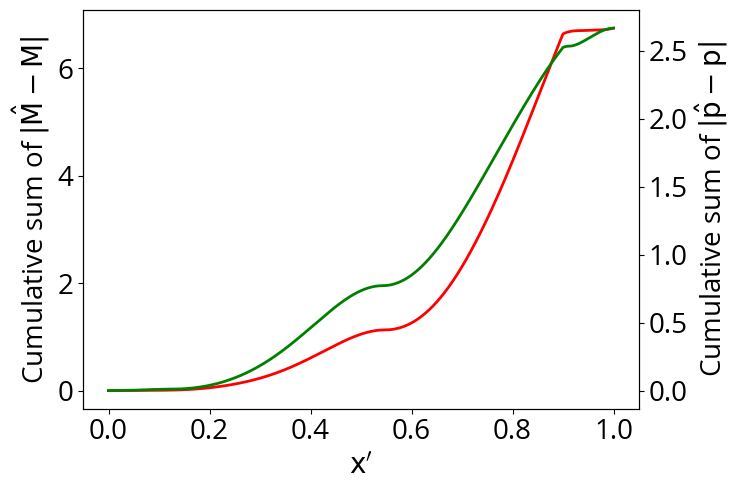

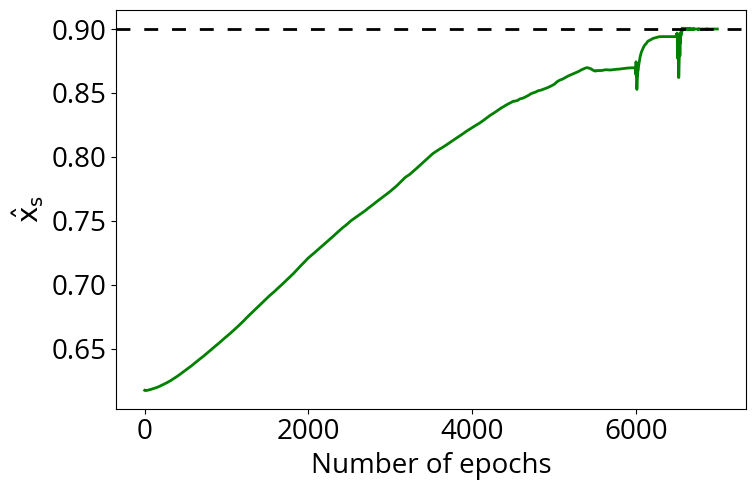

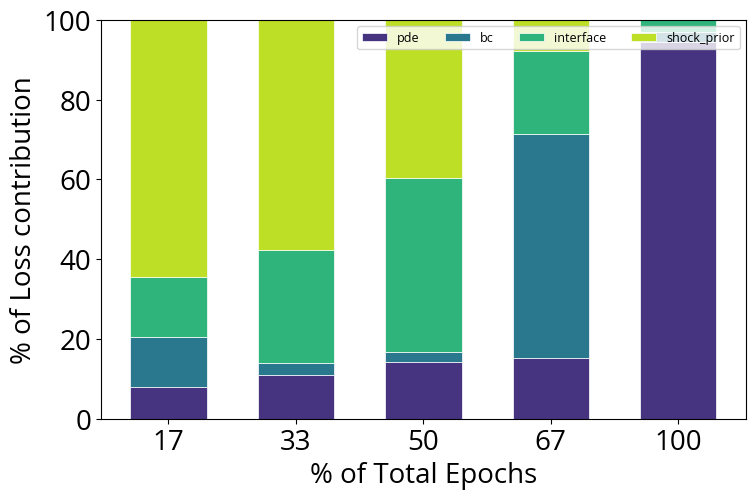

VARIANT D

Variant D shock location: 0.900114  (target: 0.9000)


/tmp/ipykernel_11924/2487256954.py:59: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/tmp/ipykernel_11924/2487256954.py:103: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


Variant D final shock location: 0.900114  (target: 0.9000)
L2 error (M): mean=2.1697e-03  max=8.1094e-03
L2 error (p): mean=9.8552e-04  max=2.2143e-03


/tmp/ipykernel_11924/2487256954.py:233: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


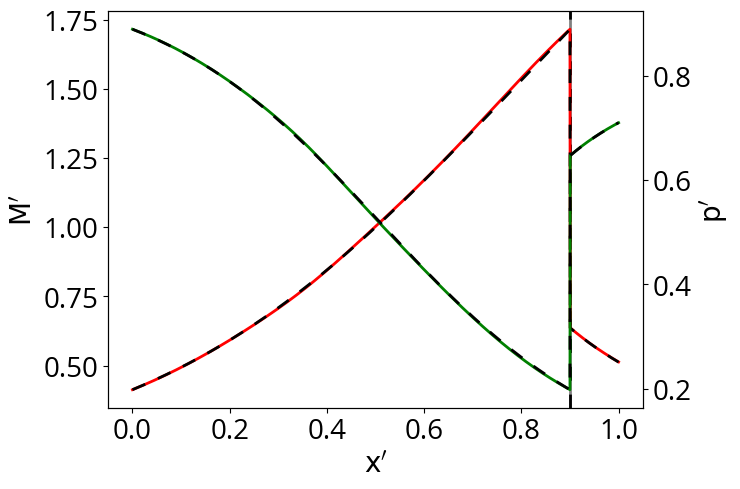

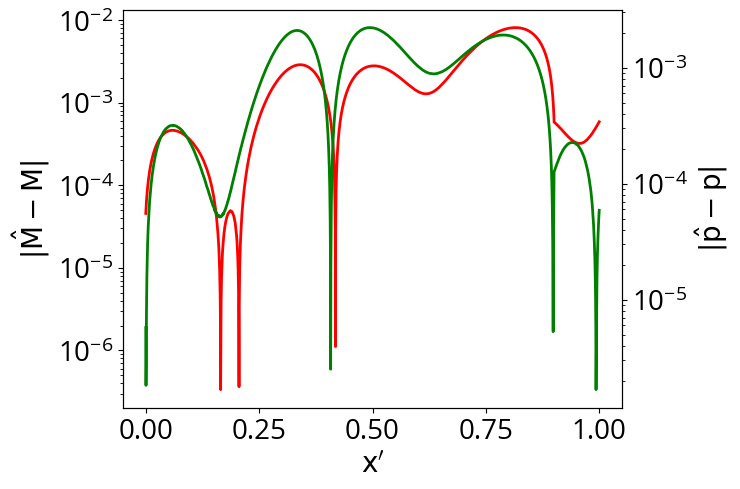

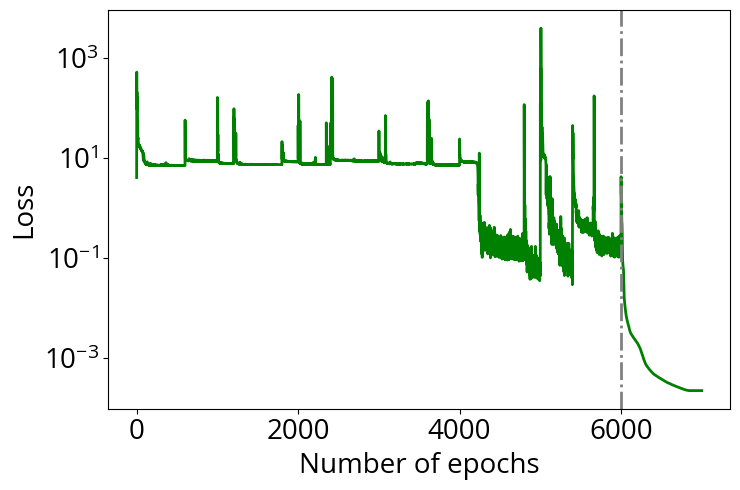

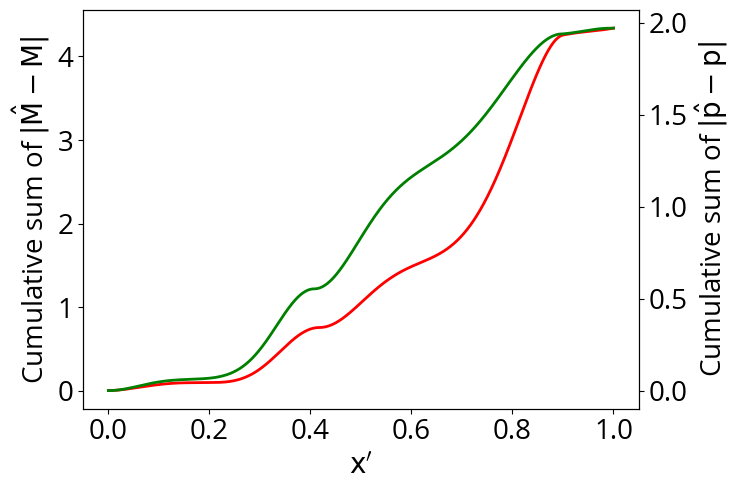

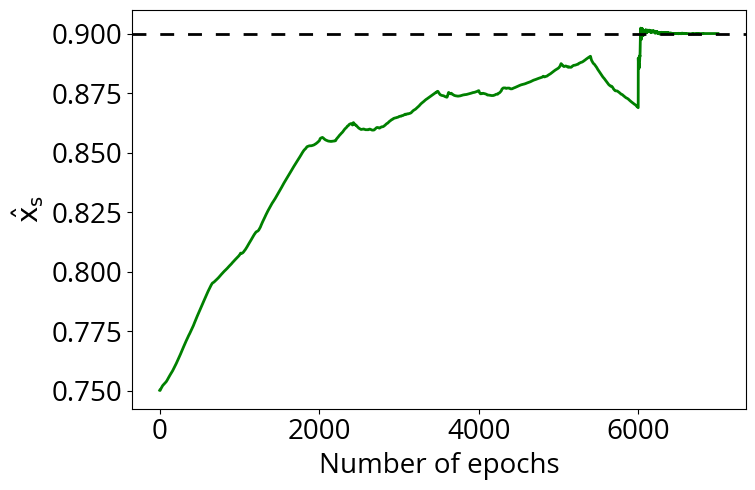

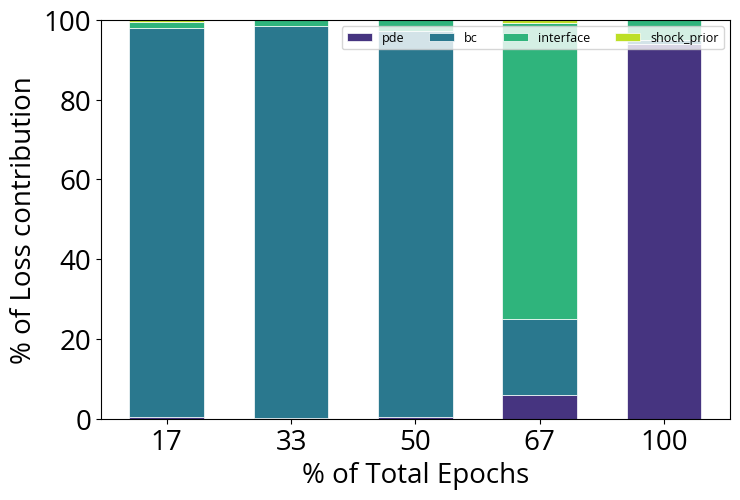


All variant plots saved under: /home/prantik/projects/qsnippets/07_cd_nozzle/variants/plots


In [30]:
# ── Variants A-D: build evaluation data & generate all diagnostic plots ─────
# Each variant's six diagnostics (M/p profiles, L2 error profiles, loss curve,
# L2 error CDF, shock convergence, loss composition) are saved as SEPARATE
# PNG files, one variant per folder under `plots/`.

PLOTS_ROOT = "plots"
SHOW_PLOTS = True  # set False to only save to disk without displaying inline


def build_variant_plots(
    variant: str,
    pre_model: "UnsteadyNet",
    post_model: "UnsteadyNet",
    shock_param: "ShockParam",
    loss_history: list,
    x_shock_target: float,
    analytical_M: np.ndarray,
    analytical_P: np.ndarray,
    color: str,
    out_dir: str,
):
    os.makedirs(out_dir, exist_ok=True)

    shock_at = shock_param.clamped_x().item()
    print(f"\nVariant {variant} shock location: {shock_at:.6f}  (target: {x_shock_target:.4f})")

    x_eval_np = np.linspace(X_START, X_START + X_LENGTH, EVAL_PRED_POINTS)
    x_ten = torch.tensor(x_eval_np, dtype=torch.float32, device=device)
    t_ten = torch.full_like(x_ten, T_STEADY)
    xt_eval = torch.stack([x_ten, t_ten], dim=1)

    pre_model.eval()
    post_model.eval()
    mask_pre = x_eval_np < shock_at
    mask_post = ~mask_pre

    with torch.no_grad():
        out_pre = pre_model(xt_eval[mask_pre])  # type: ignore
        out_post = post_model(xt_eval[mask_post])  # type: ignore

    def _mach_pack(out):
        rho, u, P, T = (out[:, i].cpu().numpy() for i in range(4))
        M = u / np.sqrt(GAMMA * P / rho)
        return rho, u, P, T, M

    rho_pre, u_pre, P_pre, T_pre, M_pre = _mach_pack(out_pre)
    rho_post, u_post, P_post, T_post, M_post = _mach_pack(out_post)

    # stitch pre/post predictions back onto the full x grid, in x order
    M_pinn = np.empty_like(x_eval_np)
    P_pinn = np.empty_like(x_eval_np)
    M_pinn[mask_pre], M_pinn[mask_post] = M_pre, M_post
    P_pinn[mask_pre], P_pinn[mask_post] = P_pre, P_post

    data = {"M": M_pinn, "p": P_pinn}
    analytical = {"M": analytical_M, "p": analytical_P}
    err = {
        "M": np.abs(M_pinn - analytical_M),
        "p": np.abs(P_pinn - analytical_P),
    }

    x_over_L = x_eval_np / X_LENGTH

    figs = []

    # 1. M, p profiles vs analytical, with predicted + analytical shock location marked
    figs.append(plot_M_p_profiles(
        x_over_L, data, variant=variant, analytical=analytical, _color=color,
        x_shock_pred=shock_at / X_LENGTH,
        x_shock_analytical=x_shock_target / X_LENGTH,
        save_path=os.path.join(out_dir, f"variant_{variant}_M_p_profiles.svg"),
    ))

    # 2. pointwise L2 error profiles
    figs.append(plot_l2_error_profiles(
        x_over_L, err, variant=variant, color=color,
        save_path=os.path.join(out_dir, f"variant_{variant}_l2_error_profiles.svg"),
    ))

    # 3. training loss curve
    # loss_history columns: total, pde_L, pde_R, bc_L, bc_R, interface, x_shock
    dl = np.array(loss_history)
    epochs = np.arange(len(dl))
    figs.append(plot_loss_curve(
        epochs, dl[:, 0], variant=variant, adam_iters=DUAL_NET_ADAM_EPOCHS, color=color,
        save_path=os.path.join(out_dir, f"variant_{variant}_loss_curve.svg"),
    ))

    # 4. CDF of pointwise L2 error
    figs.append(plot_l2_error_cdf(
        x_over_L, err, variant=variant, color=color,
        save_path=os.path.join(out_dir, f"variant_{variant}_l2_error_cdf.svg"),
    ))

    # 5. shock-location convergence vs epoch (col 6 = x_shock)
    figs.append(plot_shock_convergence(
        epochs, dl[:, 6], x_shock_target, variant=variant, color=color,
        save_path=os.path.join(out_dir, f"variant_{variant}_shock_convergence.svg"),
    ))

    print(f"Variant {variant} final shock location: {shock_at:.6f}  (target: {x_shock_target:.4f})")
    print(f"L2 error (M): mean={err['M'].mean():.4e}  max={err['M'].max():.4e}")
    print(f"L2 error (p): mean={err['p'].mean():.4e}  max={err['p'].max():.4e}")

    # 6. loss composition (stacked bar) at selected epochs
    #   pde         = pde_L + pde_R
    #   bc          = DUAL_NET_BC_WEIGHT        * (bc_L + bc_R)
    #   interface   = DUAL_NET_INTERFACE_WEIGHT * interface
    #   shock_prior = DUAL_NET_SHOCK_PRIOR_WEIGHT * (x_shock - x_shock_target)**2
    n_epochs = len(dl)
    epochs_to_show = tuple(
        e for e in (n_epochs // 6, n_epochs // 3, n_epochs // 2,
                    2 * n_epochs // 3, n_epochs - 1)
        if e < n_epochs
    )

    components_raw = {}
    for e in epochs_to_show:
        pde_L_e, pde_R_e, bc_L_e, bc_R_e, interface_e, xshock_e = dl[e, 1:7]
        components_raw[e] = {
            "pde": pde_L_e + pde_R_e,
            "bc": DUAL_NET_BC_WEIGHT * (bc_L_e + bc_R_e),
            "interface": DUAL_NET_INTERFACE_WEIGHT * interface_e,
            "shock_prior": DUAL_NET_SHOCK_PRIOR_WEIGHT * (xshock_e - x_shock_target) ** 2,
        }

    # express each epoch's stack as a PERCENTAGE of that epoch's total loss
    # (each bar sums to 100%), instead of the raw/absolute contribution
    components_pct = {
        e: {term: 100.0 * val / sum(vals.values()) for term, val in vals.items()}
        for e, vals in components_raw.items()
    }

    loss_comp_path = os.path.join(out_dir, f"variant_{variant}_loss_composition.svg")
    fig_loss_comp = plot_loss_composition(
        components_pct, variant=variant, epochs_to_show=epochs_to_show,
        terms=("pde", "bc", "interface", "shock_prior"),
        total_epochs=n_epochs,  # -> x-ticks shown as "% of training" instead of raw epoch counts
        save_path=None,  # save after relabeling the axis below
    )
    ax_lc = fig_loss_comp.axes[0]
    ax_lc.set_ylabel("% of Loss contribution", fontsize=20)
    ax_lc.set_ylim(0, 100)
    fig_loss_comp.savefig(loss_comp_path)
    figs.append(fig_loss_comp)

    if SHOW_PLOTS:
        for fig in figs:
            plt.show()
    else:
        for fig in figs:
            plt.close(fig)

    return {"shock_at": shock_at, "err": err}


# ── Per-variant configuration ────────────────────────────────────────────
# All variants (A-D) are now compared against the UPDATED analytical
# solution, `analytic_new`, whose shock sits at x_shock = 0.9.
# `analytic_new.x_shock` is read directly off the AnalyticSolution object so
# this doesn't depend on X_SHOCK_REF/X_SHOCK_NEW having been reassigned
# elsewhere in the notebook.
VARIANT_CONFIG = {
    "A": dict(
        pre_model=pre_model_A, post_model=post_model_A, shock_param=shock_param_A,
        loss_history=dual_history_A, x_shock_target=analytic_new.x_shock,
        analytical_M=analytic_new.M, analytical_P=analytic_new.P,
        color="tab:blue", out_dir=os.path.join(PLOTS_ROOT, "VARIANT_A"),
    ),
    "B": dict(
        pre_model=pre_model_B, post_model=post_model_B, shock_param=shock_param_B,
        loss_history=dual_history_B, x_shock_target=analytic_new.x_shock,
        analytical_M=analytic_new.M, analytical_P=analytic_new.P,
        color="tab:green", out_dir=os.path.join(PLOTS_ROOT, "VARIANT_B"),
    ),
    "C": dict(
        pre_model=pre_C, post_model=post_C, shock_param=shock_C,
        loss_history=loss_history_C, x_shock_target=analytic_new.x_shock,
        analytical_M=analytic_new.M, analytical_P=analytic_new.P,
        color="tab:orange", out_dir=os.path.join(PLOTS_ROOT, "VARIANT_C"),
    ),
    "D": dict(
        pre_model=pre_D, post_model=post_D, shock_param=shock_D,
        loss_history=loss_history_D, x_shock_target=analytic_new.x_shock,
        analytical_M=analytic_new.M, analytical_P=analytic_new.P,
        color="tab:red", out_dir=os.path.join(PLOTS_ROOT, "VARIANT_D"),
    ),
}

variant_results = {}
for variant, cfg in VARIANT_CONFIG.items():
    print("=" * 60)
    print(f"VARIANT {variant}")
    print("=" * 60)
    variant_results[variant] = build_variant_plots(variant=variant, **cfg) # type: ignore

print("\nAll variant plots saved under:", os.path.abspath(PLOTS_ROOT))

In [109]:
# delete the png in /plots/VARIANT_*/ that was generated by the loss composition function
def delete_loss_comp_pngs(plots_root):
    for variant in VARIANT_CONFIG.keys():
        loss_comp_path = os.path.join(plots_root, f"VARIANT_{variant}", f"variant_VARIANT_{variant}_l2_error_cdf.png")
        if os.path.exists(loss_comp_path):
            os.remove(loss_comp_path)
            print(f"Deleted {loss_comp_path}")
        else:
            print(f"No loss composition PNG found for VARIANT_{variant} at {loss_comp_path}")

delete_loss_comp_pngs(PLOTS_ROOT)

No loss composition PNG found for VARIANT_A at plots/VARIANT_A/variant_VARIANT_A_l2_error_cdf.png
No loss composition PNG found for VARIANT_B at plots/VARIANT_B/variant_VARIANT_B_l2_error_cdf.png
No loss composition PNG found for VARIANT_C at plots/VARIANT_C/variant_VARIANT_C_l2_error_cdf.png
No loss composition PNG found for VARIANT_D at plots/VARIANT_D/variant_VARIANT_D_l2_error_cdf.png
